<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/pronosticos_tesis_con_ltsm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


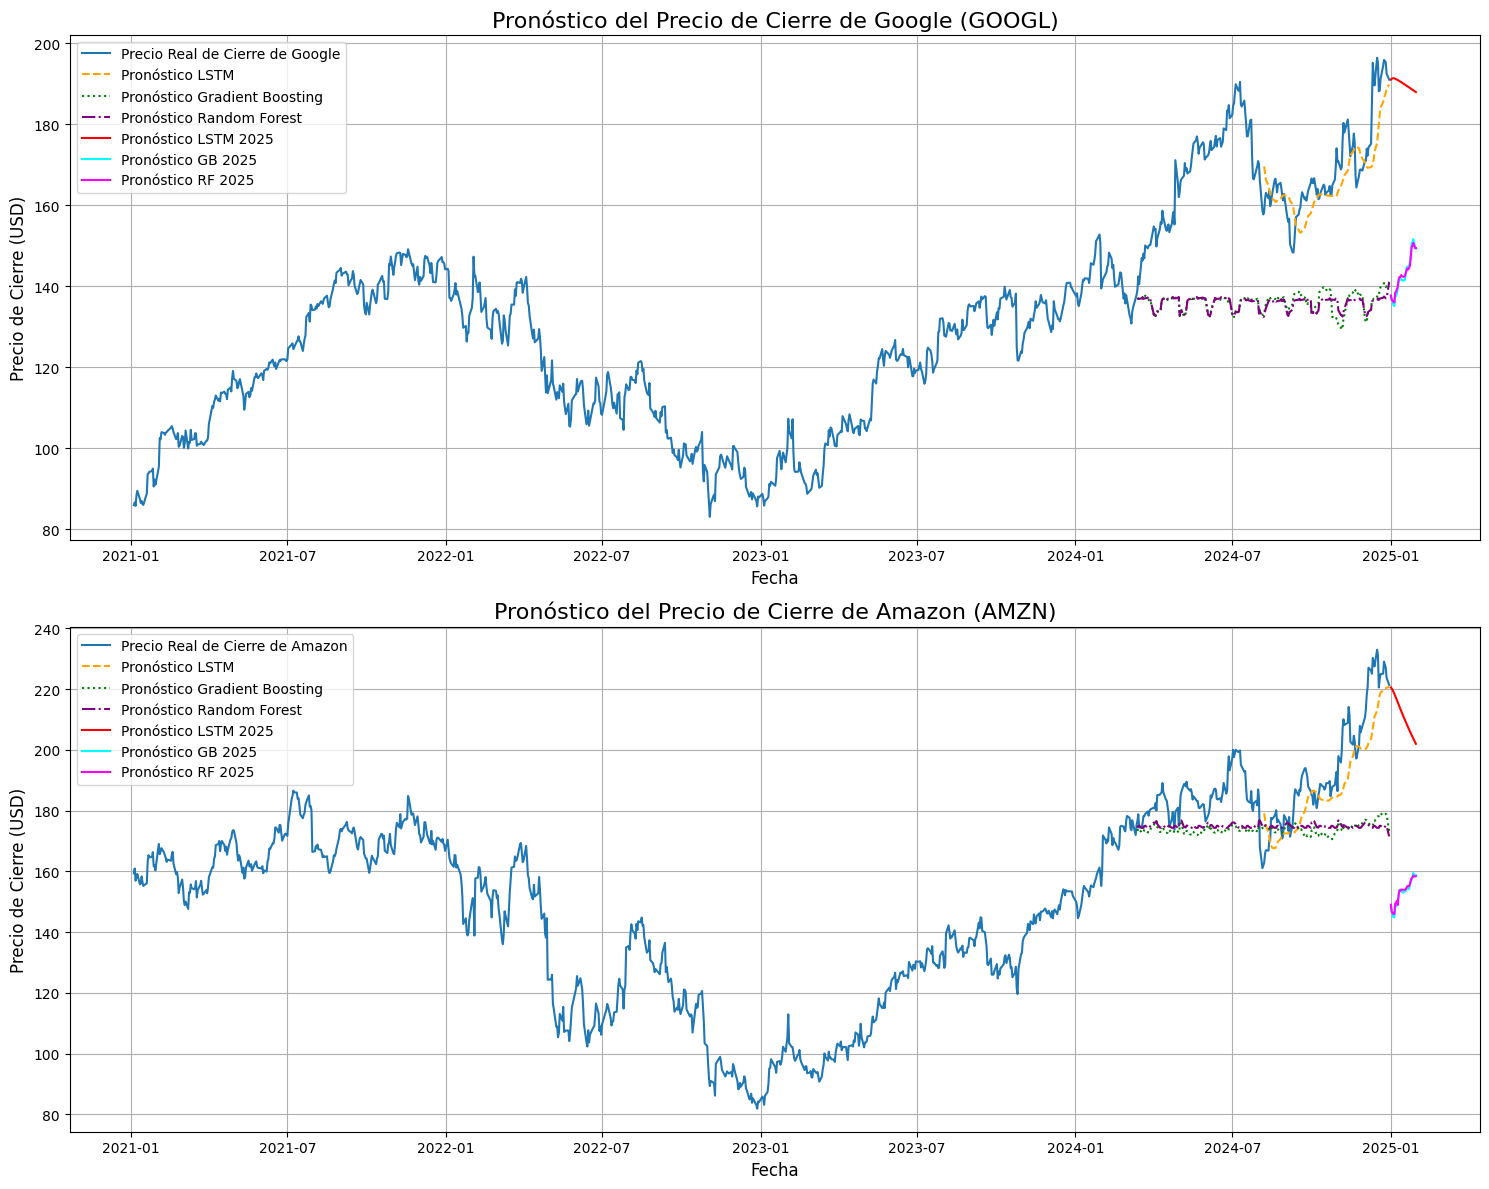


Comparación de MSE para Google:
MSE de LSTM: 48.00
MSE de Gradient Boosting: 1188.38
MSE de Random Forest: 1203.38

Comparación de MSE para Amazon:
MSE de LSTM: 100.50
MSE de Gradient Boosting: 438.52
MSE de Random Forest: 436.20


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense
import tensorflow as tf

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/jaimeisaac2020/Python-analsisis-basicos/mi-github/dataset_completo_google_amazon.csv')

# Preprocess the data
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Select the target variables
target_google = 'GOOGL_Close'
target_amazon = 'AMZN_Close'

# Prepare the data for LSTM
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X.append(a)
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# LSTM Model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train and forecast with LSTM for Google
google_df = df[[target_google]]
scaler_google = MinMaxScaler(feature_range=(0, 1))
scaled_google = scaler_google.fit_transform(np.array(google_df).reshape(-1, 1))
training_size_google = int(len(scaled_google) * 0.8)
train_data_google, test_data_google = scaled_google[0:training_size_google, :], scaled_google[training_size_google:len(scaled_google), :1]
time_step = 100
X_train_google, y_train_google = create_dataset(train_data_google, time_step)
X_test_google, y_test_google = create_dataset(test_data_google, time_step)
X_train_google = X_train_google.reshape(X_train_google.shape[0], X_train_google.shape[1], 1)
X_test_google = X_test_google.reshape(X_test_google.shape[0], X_test_google.shape[1], 1)

lstm_model_google = build_lstm_model((time_step, 1))
lstm_model_google.fit(X_train_google, y_train_google, epochs=10, batch_size=64, verbose=0)
train_predict_google = lstm_model_google.predict(X_train_google)
test_predict_google = lstm_model_google.predict(X_test_google)
train_predict_google = scaler_google.inverse_transform(train_predict_google)
test_predict_google = scaler_google.inverse_transform(test_predict_google)
lstm_google_mse = mean_squared_error(scaler_google.inverse_transform(y_test_google.reshape(-1, 1)), test_predict_google)

# Forecast for 2025 using LSTM for Google
last_100_days_google = scaled_google[len(scaled_google) - 100:].reshape(1, -1)
temp_input_google = list(last_100_days_google)
temp_input_google = temp_input_google[0].tolist()
lstm_forecast_google = []
n_steps = 100
i = 0
while(i < 30):  # Forecast for 30 days
    if len(temp_input_google) > 100:
        x_input = np.array(temp_input_google[1:])
        x_input = x_input.reshape(1, -1)
        x_input = x_input.reshape((1, n_steps, 1))
        yhat = lstm_model_google.predict(x_input, verbose=0)
        temp_input_google.extend(yhat[0].tolist())
        temp_input_google = temp_input_google[1:]
        lstm_forecast_google.extend(yhat.tolist())
        i = i + 1
    else:
        x_input = temp_input_google
        x_input = np.array(x_input).reshape((1, n_steps, 1))
        yhat = lstm_model_google.predict(x_input, verbose=0)
        temp_input_google.extend(yhat[0].tolist())
        lstm_forecast_google.extend(yhat.tolist())
        i = i + 1
lstm_forecast_google = scaler_google.inverse_transform(np.array(lstm_forecast_google).reshape(-1, 1))

# Train and forecast with LSTM for Amazon
amazon_df = df[[target_amazon]]
scaler_amazon = MinMaxScaler(feature_range=(0, 1))
scaled_amazon = scaler_amazon.fit_transform(np.array(amazon_df).reshape(-1, 1))
training_size_amazon = int(len(scaled_amazon) * 0.8)
train_data_amazon, test_data_amazon = scaled_amazon[0:training_size_amazon, :], scaled_amazon[training_size_amazon:len(scaled_amazon), :1]
X_train_amazon, y_train_amazon = create_dataset(train_data_amazon, time_step)
X_test_amazon, y_test_amazon = create_dataset(test_data_amazon, time_step)
X_train_amazon = X_train_amazon.reshape(X_train_amazon.shape[0], X_train_amazon.shape[1], 1)
X_test_amazon = X_test_amazon.reshape(X_test_amazon.shape[0], X_test_amazon.shape[1], 1)

lstm_model_amazon = build_lstm_model((time_step, 1))
lstm_model_amazon.fit(X_train_amazon, y_train_amazon, epochs=10, batch_size=64, verbose=0)
train_predict_amazon = lstm_model_amazon.predict(X_train_amazon)
test_predict_amazon = lstm_model_amazon.predict(X_test_amazon)
train_predict_amazon = scaler_amazon.inverse_transform(train_predict_amazon)
test_predict_amazon = scaler_amazon.inverse_transform(test_predict_amazon)
lstm_amazon_mse = mean_squared_error(scaler_amazon.inverse_transform(y_test_amazon.reshape(-1, 1)), test_predict_amazon)

# Forecast for 2025 using LSTM for Amazon
last_100_days_amazon = scaled_amazon[len(scaled_amazon) - 100:].reshape(1, -1)
temp_input_amazon = list(last_100_days_amazon)
temp_input_amazon = temp_input_amazon[0].tolist()
lstm_forecast_amazon = []
n_steps = 100
i = 0
while(i < 30):
    if len(temp_input_amazon) > 100:
        x_input = np.array(temp_input_amazon[1:])
        x_input = x_input.reshape(1, -1)
        x_input = x_input.reshape((1, n_steps, 1))
        yhat = lstm_model_amazon.predict(x_input, verbose=0)
        temp_input_amazon.extend(yhat[0].tolist())
        temp_input_amazon = temp_input_amazon[1:]
        lstm_forecast_amazon.extend(yhat.tolist())
        i = i + 1
    else:
        x_input = temp_input_amazon
        x_input = np.array(x_input).reshape((1, n_steps, 1))
        yhat = lstm_model_amazon.predict(x_input, verbose=0)
        temp_input_amazon.extend(yhat[0].tolist())
        lstm_forecast_amazon.extend(yhat.tolist())
        i = i + 1
lstm_forecast_amazon = scaler_amazon.inverse_transform(np.array(lstm_forecast_amazon).reshape(-1, 1))

# Prepare data for Gradient Boosting and Random Forest
def create_features(data):
    data = data.copy()
    data['dayofweek'] = data.index.dayofweek
    data['quarter'] = data.index.quarter
    data['month'] = data.index.month
    data['year'] = data.index.year
    data['dayofyear'] = data.index.dayofyear
    data['dayofmonth'] = data.index.day
    data['weekofyear'] = data.index.isocalendar().week
    return data

df_features = create_features(df)
train_size = int(len(df_features) * 0.8)
df_train_features = df_features.iloc[:train_size]
df_test_features = df_features.iloc[train_size:]

features = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear']

# Gradient Boosting for Google
gb_model_google = GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, subsample=0.7, random_state=42)
gb_model_google.fit(df_train_features[features], df_train_features[target_google])
gb_preds_google = gb_model_google.predict(df_test_features[features])
gb_google_mse = mean_squared_error(df_test_features[target_google], gb_preds_google)

# Random Forest for Google
rf_model_google = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_split=2, random_state=42)
rf_model_google.fit(df_train_features[features], df_train_features[target_google])
rf_preds_google = rf_model_google.predict(df_test_features[features])
rf_google_mse = mean_squared_error(df_test_features[target_google], rf_preds_google)

# Gradient Boosting for Amazon
gb_model_amazon = GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, subsample=0.7, random_state=42)
gb_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
gb_preds_amazon = gb_model_amazon.predict(df_test_features[features])
gb_amazon_mse = mean_squared_error(df_test_features[target_amazon], gb_preds_amazon)

# Random Forest for Amazon
rf_model_amazon = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_split=2, random_state=42)
rf_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
rf_preds_amazon = rf_model_amazon.predict(df_test_features[features])
rf_amazon_mse = mean_squared_error(df_test_features[target_amazon], rf_preds_amazon)

# Create 2025 forecast dataframes
forecast_dates = pd.date_range(start='2025-01-01', periods=30)
forecast_df_2025 = pd.DataFrame(index=forecast_dates)
forecast_df_2025 = create_features(forecast_df_2025)

# Forecast for 2025 using Gradient Boosting and Random Forest
gb_forecast_google_2025 = gb_model_google.predict(forecast_df_2025[features])
rf_forecast_google_2025 = rf_model_google.predict(forecast_df_2025[features])
gb_forecast_amazon_2025 = gb_model_amazon.predict(forecast_df_2025[features])
rf_forecast_amazon_2025 = rf_model_amazon.predict(forecast_df_2025[features])

# Plotting the results
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12))

# Google Plots
axes[0].plot(df.index, df[target_google], label='Precio Real de Cierre de Google')
axes[0].plot(df.index[training_size_google + 101:], test_predict_google, label='Pronóstico LSTM', linestyle='--', color='orange')
axes[0].plot(df_test_features.index, gb_preds_google, label='Pronóstico Gradient Boosting', linestyle=':', color='green')
axes[0].plot(df_test_features.index, rf_preds_google, label='Pronóstico Random Forest', linestyle='-.', color='purple')
axes[0].plot(forecast_dates, lstm_forecast_google, label='Pronóstico LSTM 2025', color='red')
axes[0].plot(forecast_dates, gb_forecast_google_2025, label='Pronóstico GB 2025', color='cyan')
axes[0].plot(forecast_dates, rf_forecast_google_2025, label='Pronóstico RF 2025', color='magenta')
axes[0].set_title('Pronóstico del Precio de Cierre de Google (GOOGL)', fontsize=16)
axes[0].set_xlabel('Fecha', fontsize=12)
axes[0].set_ylabel('Precio de Cierre (USD)', fontsize=12)
axes[0].legend()
axes[0].grid(True)

# Amazon Plots
axes[1].plot(df.index, df[target_amazon], label='Precio Real de Cierre de Amazon')
axes[1].plot(df.index[training_size_amazon + 101:], test_predict_amazon, label='Pronóstico LSTM', linestyle='--', color='orange')
axes[1].plot(df_test_features.index, gb_preds_amazon, label='Pronóstico Gradient Boosting', linestyle=':', color='green')
axes[1].plot(df_test_features.index, rf_preds_amazon, label='Pronóstico Random Forest', linestyle='-.', color='purple')
axes[1].plot(forecast_dates, lstm_forecast_amazon, label='Pronóstico LSTM 2025', color='red')
axes[1].plot(forecast_dates, gb_forecast_amazon_2025, label='Pronóstico GB 2025', color='cyan')
axes[1].plot(forecast_dates, rf_forecast_amazon_2025, label='Pronóstico RF 2025', color='magenta')
axes[1].set_title('Pronóstico del Precio de Cierre de Amazon (AMZN)', fontsize=16)
axes[1].set_xlabel('Fecha', fontsize=12)
axes[1].set_ylabel('Precio de Cierre (USD)', fontsize=12)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Compare MSE
print("\nComparación de MSE para Google:")
print(f"MSE de LSTM: {lstm_google_mse:.2f}")
print(f"MSE de Gradient Boosting: {gb_google_mse:.2f}")
print(f"MSE de Random Forest: {rf_google_mse:.2f}")

print("\nComparación de MSE para Amazon:")
print(f"MSE de LSTM: {lstm_amazon_mse:.2f}")
print(f"MSE de Gradient Boosting: {gb_amazon_mse:.2f}")
print(f"MSE de Random Forest: {rf_amazon_mse:.2f}")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/jaimeisaac2020/Python-analsisis-basicos/mi-github/dataset_completo_google_amazon.csv')

# Preprocess the data
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Select the target variables
target_google = 'GOOGL_Close'
target_amazon = 'AMZN_Close'

# --- Function to prepare data for LSTM ---
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X.append(a)
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# --- Build the LSTM model ---
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# --- Prepare data for all models ---
def create_features(data):
    data = data.copy()
    data['dayofweek'] = data.index.dayofweek
    data['quarter'] = data.index.quarter
    data['month'] = data.index.month
    data['year'] = data.index.year
    data['dayofyear'] = data.index.dayofyear
    data['dayofmonth'] = data.index.day
    data['weekofyear'] = data.index.isocalendar().week
    return data

df_features = create_features(df)
train_size = int(len(df_features) * 0.8)
df_train_features = df_features.iloc[:train_size]
df_test_features = df_features.iloc[train_size:]
features = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear']

# --- LSTM Model ---
# Google
google_df = df[[target_google]]
scaler_google = MinMaxScaler(feature_range=(0, 1))
scaled_google = scaler_google.fit_transform(np.array(google_df).reshape(-1, 1))
training_size_google = int(len(scaled_google) * 0.8)
train_data_google, test_data_google = scaled_google[0:training_size_google, :], scaled_google[training_size_google:len(scaled_google), :1]
time_step = 100
X_train_google, y_train_google = create_dataset(train_data_google, time_step)
X_test_google, y_test_google = create_dataset(test_data_google, time_step)
X_train_google = X_train_google.reshape(X_train_google.shape[0], X_train_google.shape[1], 1)
X_test_google = X_test_google.reshape(X_test_google.shape[0], X_test_google.shape[1], 1)
lstm_model_google = build_lstm_model((time_step, 1))
lstm_model_google.fit(X_train_google, y_train_google, epochs=10, batch_size=64, verbose=0)
test_predict_google_lstm = lstm_model_google.predict(X_test_google)
test_predict_google_lstm = scaler_google.inverse_transform(test_predict_google_lstm)
lstm_google_mse = mean_squared_error(scaler_google.inverse_transform(y_test_google.reshape(-1, 1)), test_predict_google_lstm)

# Amazon
amazon_df = df[[target_amazon]]
scaler_amazon = MinMaxScaler(feature_range=(0, 1))
scaled_amazon = scaler_amazon.fit_transform(np.array(amazon_df).reshape(-1, 1))
training_size_amazon = int(len(scaled_amazon) * 0.8)
train_data_amazon, test_data_amazon = scaled_amazon[0:training_size_amazon, :], scaled_amazon[training_size_amazon:len(scaled_amazon), :1]
X_train_amazon, y_train_amazon = create_dataset(train_data_amazon, time_step)
X_test_amazon, y_test_amazon = create_dataset(test_data_amazon, time_step)
X_train_amazon = X_train_amazon.reshape(X_train_amazon.shape[0], X_train_amazon.shape[1], 1)
X_test_amazon = X_test_amazon.reshape(X_test_amazon.shape[0], X_test_amazon.shape[1], 1)
lstm_model_amazon = build_lstm_model((time_step, 1))
lstm_model_amazon.fit(X_train_amazon, y_train_amazon, epochs=10, batch_size=64, verbose=0)
test_predict_amazon_lstm = lstm_model_amazon.predict(X_test_amazon)
test_predict_amazon_lstm = scaler_amazon.inverse_transform(test_predict_amazon_lstm)
lstm_amazon_mse = mean_squared_error(scaler_amazon.inverse_transform(y_test_amazon.reshape(-1, 1)), test_predict_amazon_lstm)

# --- Linear Regression Model ---
# Google
lr_model_google = LinearRegression()
lr_model_google.fit(df_train_features[features], df_train_features[target_google])
lr_preds_google = lr_model_google.predict(df_test_features[features])
lr_google_mse = mean_squared_error(df_test_features[target_google], lr_preds_google)

# Amazon
lr_model_amazon = LinearRegression()
lr_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
lr_preds_amazon = lr_model_amazon.predict(df_test_features[features])
lr_amazon_mse = mean_squared_error(df_test_features[target_amazon], lr_preds_amazon)

# --- Gradient Boosting Model ---
# Google
gb_model_google = GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, subsample=0.7, random_state=42)
gb_model_google.fit(df_train_features[features], df_train_features[target_google])
gb_preds_google = gb_model_google.predict(df_test_features[features])
gb_google_mse = mean_squared_error(df_test_features[target_google], gb_preds_google)

# Amazon
gb_model_amazon = GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, subsample=0.7, random_state=42)
gb_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
gb_preds_amazon = gb_model_amazon.predict(df_test_features[features])
gb_amazon_mse = mean_squared_error(df_test_features[target_amazon], gb_preds_amazon)

# --- Random Forest Model ---
# Google
rf_model_google = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_split=2, random_state=42)
rf_model_google.fit(df_train_features[features], df_train_features[target_google])
rf_preds_google = rf_model_google.predict(df_test_features[features])
rf_google_mse = mean_squared_error(df_test_features[target_google], rf_preds_google)

# Amazon
rf_model_amazon = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_split=2, random_state=42)
rf_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
rf_preds_amazon = rf_model_amazon.predict(df_test_features[features])
rf_amazon_mse = mean_squared_error(df_test_features[target_amazon], rf_preds_amazon)

# --- ARIMA Model ---
# Google
arima_model_google = ARIMA(df_features[target_google].iloc[:train_size], order=(5,1,0))
arima_model_google_fit = arima_model_google.fit()
arima_preds_google = arima_model_google_fit.predict(start=len(df_train_features), end=len(df_features)-1)
arima_google_mse = mean_squared_error(df_test_features[target_google], arima_preds_google)

# Amazon
arima_model_amazon = ARIMA(df_features[target_amazon].iloc[:train_size], order=(5,1,0))
arima_model_amazon_fit = arima_model_amazon.fit()
arima_preds_amazon = arima_model_amazon_fit.predict(start=len(df_train_features), end=len(df_features)-1)
arima_amazon_mse = mean_squared_error(df_test_features[target_amazon], arima_preds_amazon)

# --- Print comparison table ---
print("\n=== Comparación de Modelos por MSE ===")
print("-" * 50)
print("Modelo\t\t\tGoogle (GOOGL) MSE\tAmazon (AMZN) MSE")
print("-" * 50)
print(f"LSTM\t\t\t{lstm_google_mse:.2f}\t\t{lstm_amazon_mse:.2f}")
print(f"Gradient Boosting\t{gb_google_mse:.2f}\t\t{gb_amazon_mse:.2f}")
print(f"Random Forest\t\t{rf_google_mse:.2f}\t\t{rf_amazon_mse:.2f}")
print(f"Regresión Lineal\t{lr_google_mse:.2f}\t\t{lr_amazon_mse:.2f}")
print(f"ARIMA\t\t\t{arima_google_mse:.2f}\t\t{arima_amazon_mse:.2f}")
print("-" * 50)

# --- Determine the best model ---
google_mses = {
    'LSTM': lstm_google_mse,
    'Gradient Boosting': gb_google_mse,
    'Random Forest': rf_google_mse,
    'Regresión Lineal': lr_google_mse,
    'ARIMA': arima_google_mse
}

amazon_mses = {
    'LSTM': lstm_amazon_mse,
    'Gradient Boosting': gb_amazon_mse,
    'Random Forest': rf_amazon_mse,
    'Regresión Lineal': lr_amazon_mse,
    'ARIMA': arima_amazon_mse
}

best_model_google = min(google_mses, key=google_mses.get)
best_model_amazon = min(amazon_mses, key=amazon_mses.get)

print(f"\nEl mejor modelo para pronosticar Google (GOOGL) es: {best_model_google}")
print(f"El mejor modelo para pronosticar Amazon (AMZN) es: {best_model_amazon}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step

=== Comparación de Modelos por MSE ===
--------------------------------------------------
Modelo			Google (GOOGL) MSE	Amazon (AMZN) MSE
--------------------------------------------------
LSTM			46.26		83.37
Gradient Boosting	1188.38		438.52
Random Forest		1203.38		436.20
Regresión Lineal	1903.97		5524.83
ARIMA			1115.96		416.02
--------------------------------------------------

El mejor modelo para pronosticar Google (GOOGL) es: LSTM
El mejor modelo para pronosticar Amazon (AMZN) es: LSTM


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step


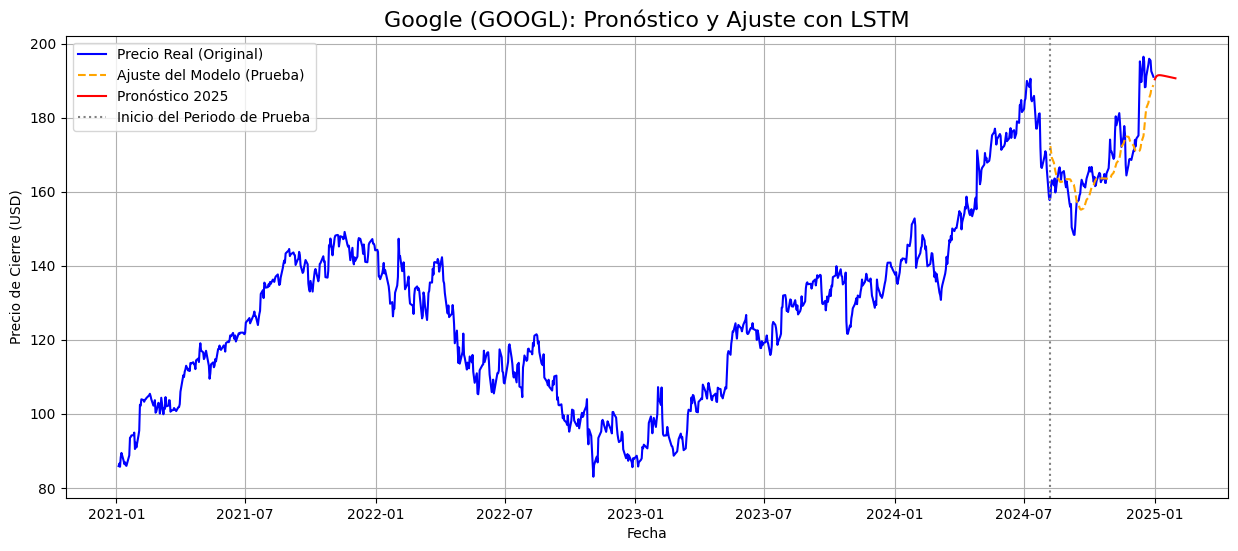

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step


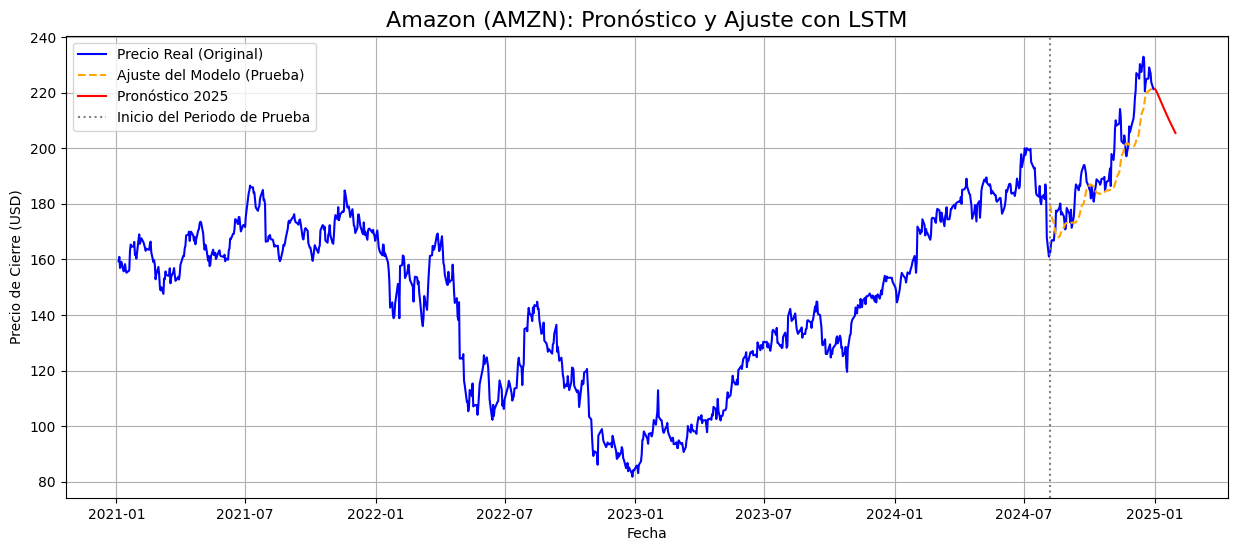

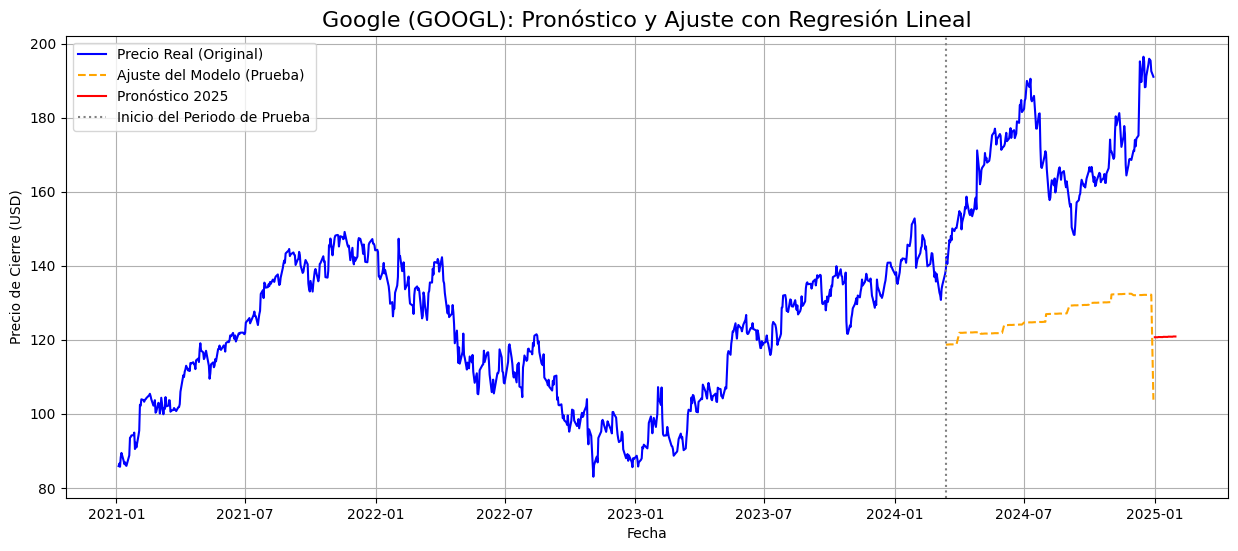

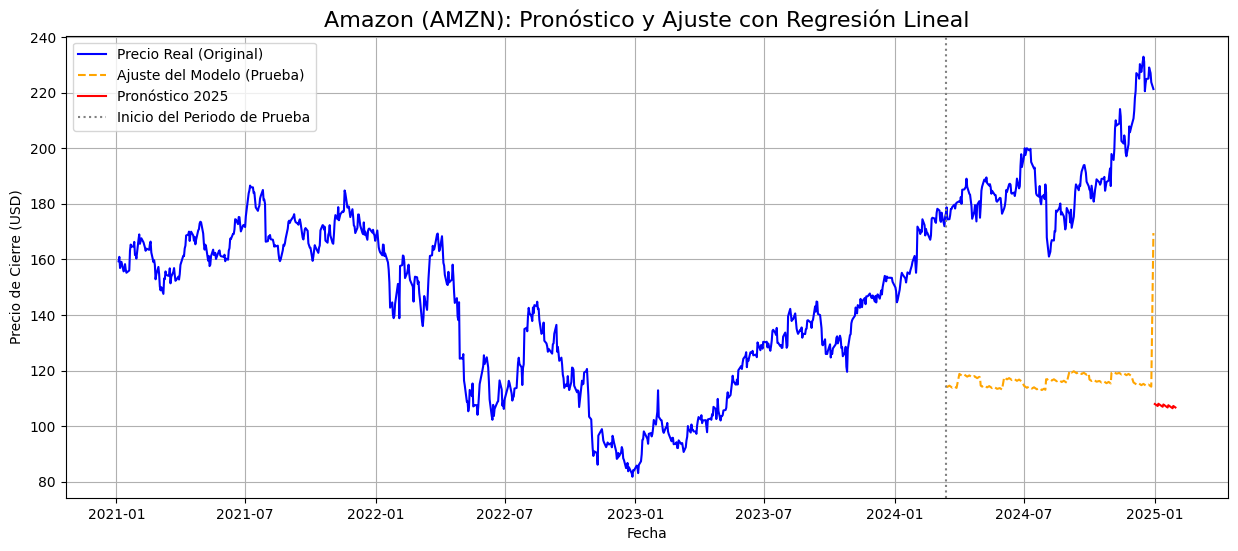

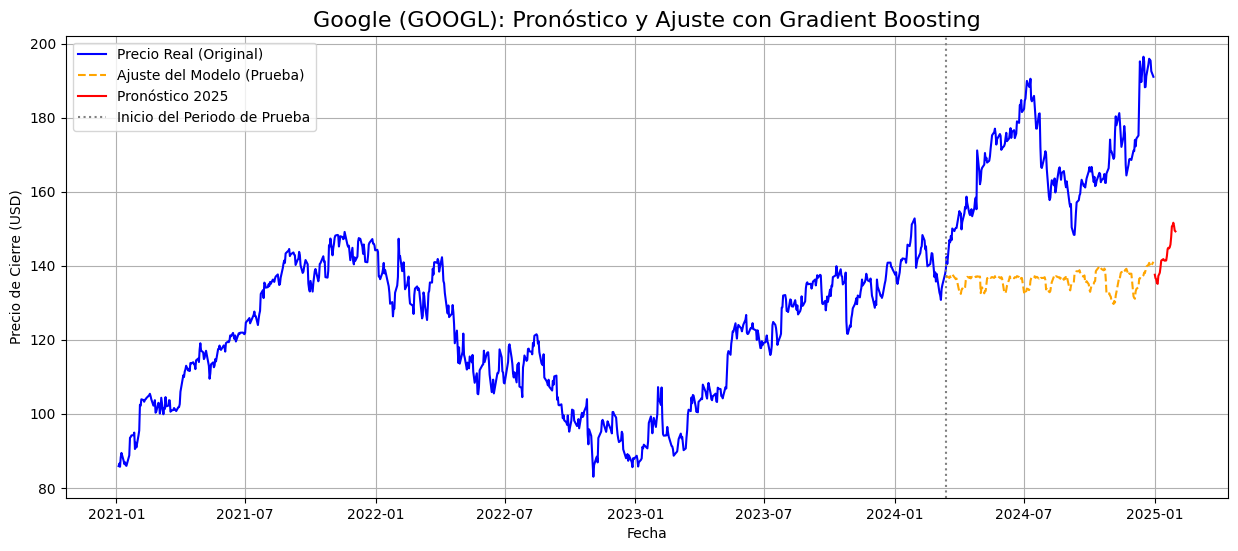

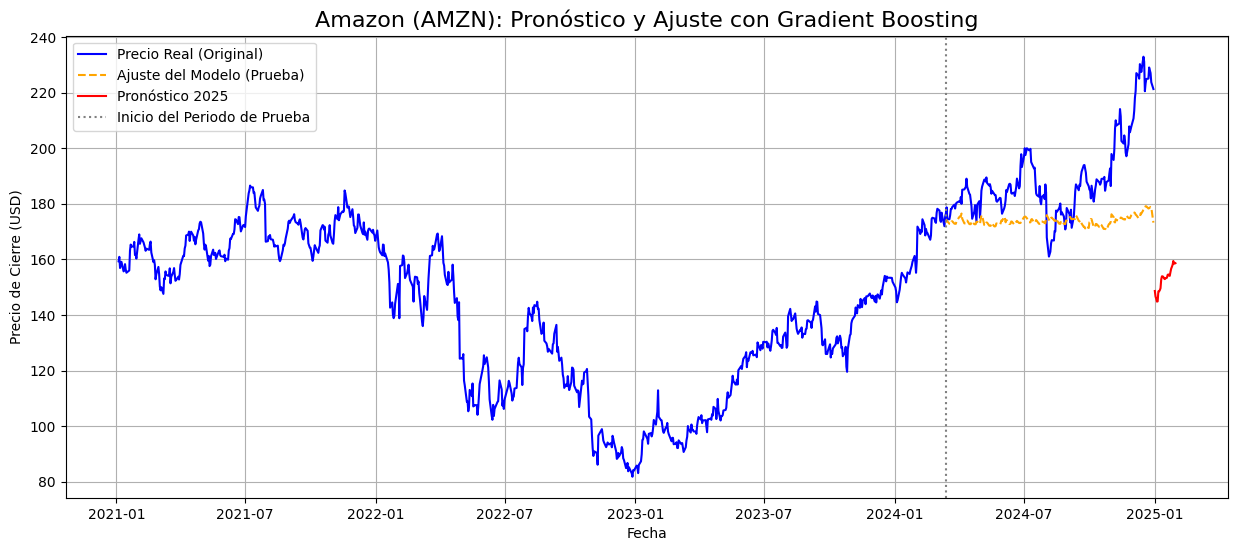

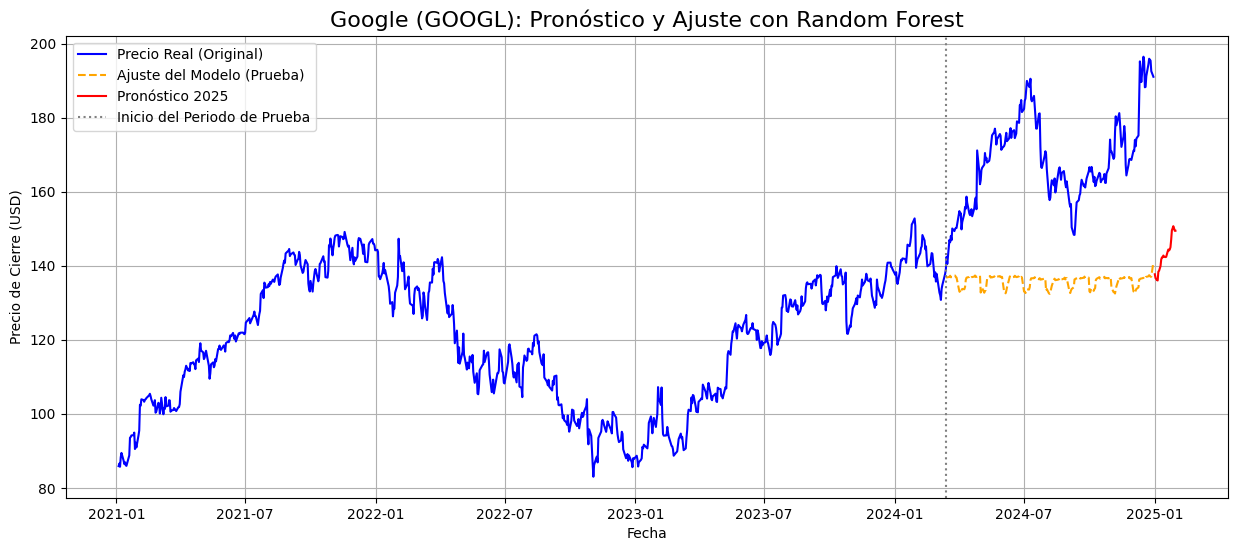

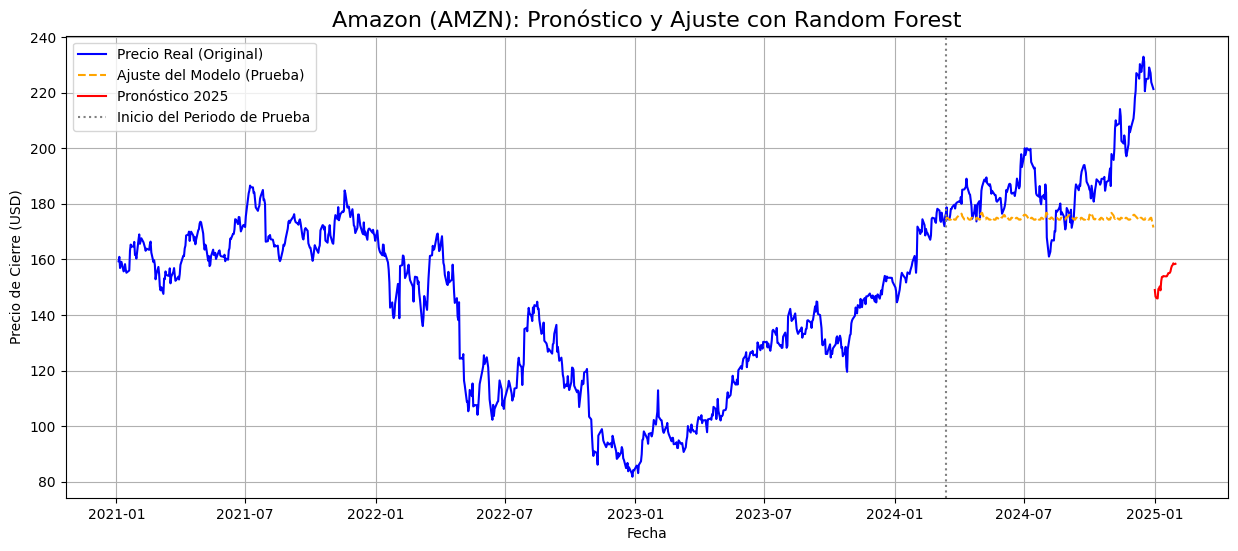

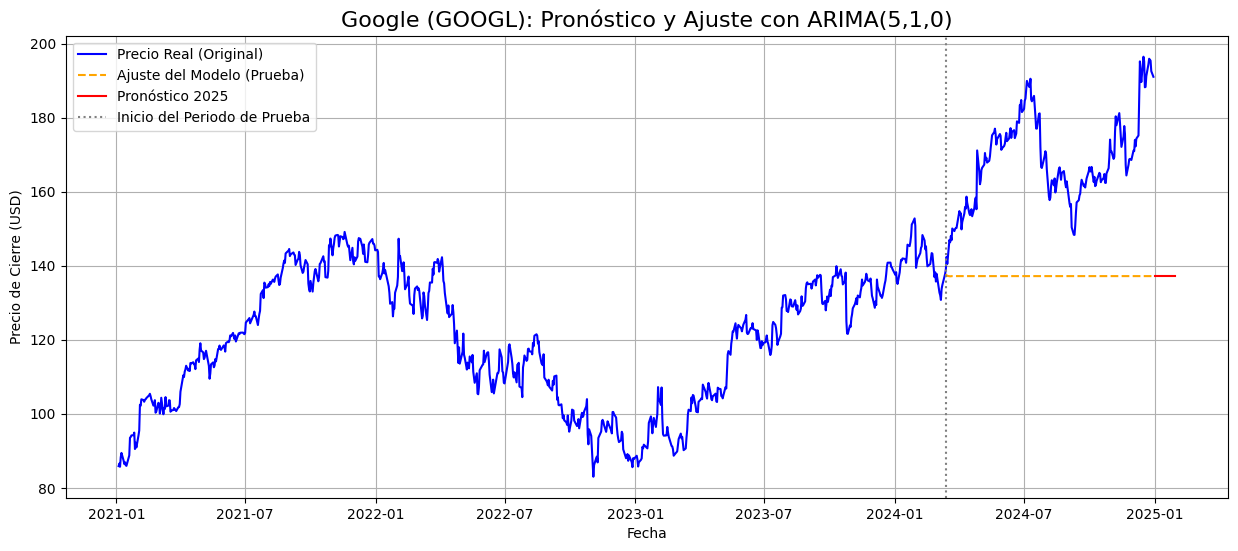

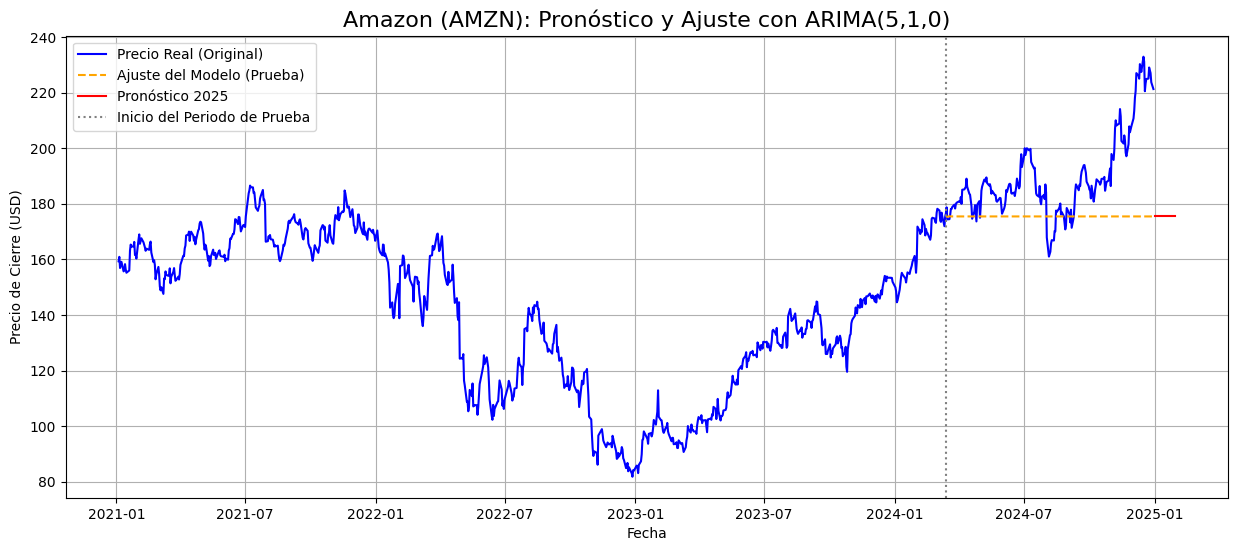


=== Comparación de Modelos por MSE ===
------------------------------------------------------------
Modelo			Google (GOOGL) MSE	Amazon (AMZN) MSE
------------------------------------------------------------
LSTM			50.94		90.15
Gradient Boosting	1188.38		438.52
Random Forest		1203.38		436.20
Regresión Lineal	1903.97		5524.83
ARIMA			1115.96		416.02
------------------------------------------------------------

El mejor modelo para pronosticar Google (GOOGL) es: LSTM (MSE: 50.94)
El mejor modelo para pronosticar Amazon (AMZN) es: LSTM (MSE: 90.15)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/jaimeisaac2020/Python-analsisis-basicos/mi-github/dataset_completo_google_amazon.csv')

# Preprocess the data
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Select the target variables
target_google = 'GOOGL_Close'
target_amazon = 'AMZN_Close'

# --- Function to prepare data for LSTM ---
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X.append(a)
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# --- Build the LSTM model ---
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# --- Prepare data for all models ---
def create_features(data):
    data = data.copy()
    data['dayofweek'] = data.index.dayofweek
    data['quarter'] = data.index.quarter
    data['month'] = data.index.month
    data['year'] = data.index.year
    data['dayofyear'] = data.index.dayofyear
    data['dayofmonth'] = data.index.day
    data['weekofyear'] = data.index.isocalendar().week
    return data

df_features = create_features(df)
train_size = int(len(df_features) * 0.8)
df_train_features = df_features.iloc[:train_size]
df_test_features = df_features.iloc[train_size:]
features = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear']

# --- Pronóstico y Gráfico para 2025 (30 días) ---
forecast_dates = pd.date_range(start='2025-01-01', periods=30)
forecast_df_2025 = pd.DataFrame(index=forecast_dates)
forecast_df_2025 = create_features(forecast_df_2025)

def plot_forecast(stock_df, test_preds, forecast_2025, test_data_index, forecast_dates, title):
    plt.figure(figsize=(15, 6))
    plt.plot(stock_df.index, stock_df.values, label='Precio Real (Original)', color='blue')

    # Ajuste en el Periodo de Prueba
    plt.plot(test_data_index, test_preds, label='Ajuste del Modelo (Prueba)', linestyle='--', color='orange')

    # Pronóstico para 2025
    plt.plot(forecast_dates, forecast_2025, label='Pronóstico 2025', color='red')

    plt.title(title, fontsize=16)
    plt.xlabel('Fecha')
    plt.ylabel('Precio de Cierre (USD)')
    plt.axvline(x=test_data_index.min(), color='gray', linestyle=':', label='Inicio del Periodo de Prueba')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 1. LSTM Model (Train, Predict, Forecast) ---

# Google LSTM
google_df_lstm = df[[target_google]]
scaler_google = MinMaxScaler(feature_range=(0, 1))
scaled_google = scaler_google.fit_transform(np.array(google_df_lstm).reshape(-1, 1))
train_data_google, test_data_google = scaled_google[0:train_size, :], scaled_google[train_size:len(scaled_google), :1]
time_step = 100
X_train_google, y_train_google = create_dataset(train_data_google, time_step)
X_test_google, y_test_google = create_dataset(test_data_google, time_step)
X_train_google = X_train_google.reshape(X_train_google.shape[0], X_train_google.shape[1], 1)
X_test_google = X_test_google.reshape(X_test_google.shape[0], X_test_google.shape[1], 1)
lstm_model_google = build_lstm_model((time_step, 1))
lstm_model_google.fit(X_train_google, y_train_google, epochs=10, batch_size=64, verbose=0)
test_predict_google_lstm_scaled = lstm_model_google.predict(X_test_google)
test_predict_google_lstm = scaler_google.inverse_transform(test_predict_google_lstm_scaled)
lstm_google_mse = mean_squared_error(scaler_google.inverse_transform(y_test_google.reshape(-1, 1)), test_predict_google_lstm)

# 2025 Forecast LSTM Google
last_100_days_google = scaled_google[len(scaled_google) - 100:].reshape(1, -1)
temp_input_google = list(last_100_days_google)[0].tolist()
lstm_forecast_google = []
for i in range(30):
    if len(temp_input_google) > 100:
        x_input = np.array(temp_input_google[1:])
    else:
        x_input = np.array(temp_input_google)
    x_input = x_input.reshape(1, 100, 1)
    yhat = lstm_model_google.predict(x_input, verbose=0)[0]
    temp_input_google.extend(yhat.tolist())
    temp_input_google = temp_input_google[1:]
    lstm_forecast_google.append(yhat.tolist())
lstm_forecast_google = scaler_google.inverse_transform(np.array(lstm_forecast_google).reshape(-1, 1))

# Plot Google LSTM
plot_forecast(
    df[[target_google]],
    test_predict_google_lstm.flatten(),
    lstm_forecast_google.flatten(),
    df.index[train_size + time_step + 1:],
    forecast_dates,
    'Google (GOOGL): Pronóstico y Ajuste con LSTM'
)


# Amazon LSTM
amazon_df_lstm = df[[target_amazon]]
scaler_amazon = MinMaxScaler(feature_range=(0, 1))
scaled_amazon = scaler_amazon.fit_transform(np.array(amazon_df_lstm).reshape(-1, 1))
train_data_amazon, test_data_amazon = scaled_amazon[0:train_size, :], scaled_amazon[train_size:len(scaled_amazon), :1]
X_train_amazon, y_train_amazon = create_dataset(train_data_amazon, time_step)
X_test_amazon, y_test_amazon = create_dataset(test_data_amazon, time_step)
X_train_amazon = X_train_amazon.reshape(X_train_amazon.shape[0], X_train_amazon.shape[1], 1)
X_test_amazon = X_test_amazon.reshape(X_test_amazon.shape[0], X_test_amazon.shape[1], 1)
lstm_model_amazon = build_lstm_model((time_step, 1))
lstm_model_amazon.fit(X_train_amazon, y_train_amazon, epochs=10, batch_size=64, verbose=0)
test_predict_amazon_lstm_scaled = lstm_model_amazon.predict(X_test_amazon)
test_predict_amazon_lstm = scaler_amazon.inverse_transform(test_predict_amazon_lstm_scaled)
lstm_amazon_mse = mean_squared_error(scaler_amazon.inverse_transform(y_test_amazon.reshape(-1, 1)), test_predict_amazon_lstm)

# 2025 Forecast LSTM Amazon
last_100_days_amazon = scaled_amazon[len(scaled_amazon) - 100:].reshape(1, -1)
temp_input_amazon = list(last_100_days_amazon)[0].tolist()
lstm_forecast_amazon = []
for i in range(30):
    if len(temp_input_amazon) > 100:
        x_input = np.array(temp_input_amazon[1:])
    else:
        x_input = np.array(temp_input_amazon)
    x_input = x_input.reshape(1, 100, 1)
    yhat = lstm_model_amazon.predict(x_input, verbose=0)[0]
    temp_input_amazon.extend(yhat.tolist())
    temp_input_amazon = temp_input_amazon[1:]
    lstm_forecast_amazon.append(yhat.tolist())
lstm_forecast_amazon = scaler_amazon.inverse_transform(np.array(lstm_forecast_amazon).reshape(-1, 1))

# Plot Amazon LSTM
plot_forecast(
    df[[target_amazon]],
    test_predict_amazon_lstm.flatten(),
    lstm_forecast_amazon.flatten(),
    df.index[train_size + time_step + 1:],
    forecast_dates,
    'Amazon (AMZN): Pronóstico y Ajuste con LSTM'
)

# --- 2. Regression-Based Models (Linear Regression, GB, RF) ---
# NOTE: The predictions are already calculated on df_test_features in the previous code block (gb_preds, rf_preds, lr_preds)

# --- Linear Regression Model ---
lr_model_google = LinearRegression()
lr_model_google.fit(df_train_features[features], df_train_features[target_google])
lr_preds_google = lr_model_google.predict(df_test_features[features])
lr_google_mse = mean_squared_error(df_test_features[target_google], lr_preds_google)
lr_forecast_google_2025 = lr_model_google.predict(forecast_df_2025[features])

# Plot Google Linear Regression
plot_forecast(
    df[[target_google]],
    lr_preds_google,
    lr_forecast_google_2025,
    df_test_features.index,
    forecast_dates,
    'Google (GOOGL): Pronóstico y Ajuste con Regresión Lineal'
)

lr_model_amazon = LinearRegression()
lr_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
lr_preds_amazon = lr_model_amazon.predict(df_test_features[features])
lr_amazon_mse = mean_squared_error(df_test_features[target_amazon], lr_preds_amazon)
lr_forecast_amazon_2025 = lr_model_amazon.predict(forecast_df_2025[features])

# Plot Amazon Linear Regression
plot_forecast(
    df[[target_amazon]],
    lr_preds_amazon,
    lr_forecast_amazon_2025,
    df_test_features.index,
    forecast_dates,
    'Amazon (AMZN): Pronóstico y Ajuste con Regresión Lineal'
)

# --- Gradient Boosting Model ---
gb_model_google = GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, subsample=0.7, random_state=42)
gb_model_google.fit(df_train_features[features], df_train_features[target_google])
gb_preds_google = gb_model_google.predict(df_test_features[features])
gb_google_mse = mean_squared_error(df_test_features[target_google], gb_preds_google)
gb_forecast_google_2025 = gb_model_google.predict(forecast_df_2025[features])

# Plot Google Gradient Boosting
plot_forecast(
    df[[target_google]],
    gb_preds_google,
    gb_forecast_google_2025,
    df_test_features.index,
    forecast_dates,
    'Google (GOOGL): Pronóstico y Ajuste con Gradient Boosting'
)

gb_model_amazon = GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, subsample=0.7, random_state=42)
gb_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
gb_preds_amazon = gb_model_amazon.predict(df_test_features[features])
gb_amazon_mse = mean_squared_error(df_test_features[target_amazon], gb_preds_amazon)
gb_forecast_amazon_2025 = gb_model_amazon.predict(forecast_df_2025[features])

# Plot Amazon Gradient Boosting
plot_forecast(
    df[[target_amazon]],
    gb_preds_amazon,
    gb_forecast_amazon_2025,
    df_test_features.index,
    forecast_dates,
    'Amazon (AMZN): Pronóstico y Ajuste con Gradient Boosting'
)

# --- Random Forest Model ---
rf_model_google = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_split=2, random_state=42)
rf_model_google.fit(df_train_features[features], df_train_features[target_google])
rf_preds_google = rf_model_google.predict(df_test_features[features])
rf_google_mse = mean_squared_error(df_test_features[target_google], rf_preds_google)
rf_forecast_google_2025 = rf_model_google.predict(forecast_df_2025[features])

# Plot Google Random Forest
plot_forecast(
    df[[target_google]],
    rf_preds_google,
    rf_forecast_google_2025,
    df_test_features.index,
    forecast_dates,
    'Google (GOOGL): Pronóstico y Ajuste con Random Forest'
)

rf_model_amazon = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_split=2, random_state=42)
rf_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
rf_preds_amazon = rf_model_amazon.predict(df_test_features[features])
rf_amazon_mse = mean_squared_error(df_test_features[target_amazon], rf_preds_amazon)
rf_forecast_amazon_2025 = rf_model_amazon.predict(forecast_df_2025[features])

# Plot Amazon Random Forest
plot_forecast(
    df[[target_amazon]],
    rf_preds_amazon,
    rf_forecast_amazon_2025,
    df_test_features.index,
    forecast_dates,
    'Amazon (AMZN): Pronóstico y Ajuste con Random Forest'
)

# --- 3. ARIMA Model (Train, Predict, Forecast) ---
# ARIMA Order(5,1,0)
arima_model_google = ARIMA(df_features[target_google].iloc[:train_size], order=(5,1,0))
arima_model_google_fit = arima_model_google.fit()
arima_preds_google = arima_model_google_fit.predict(start=len(df_train_features), end=len(df_features)-1)
arima_google_mse = mean_squared_error(df_test_features[target_google], arima_preds_google)
arima_forecast_google_2025 = arima_model_google_fit.predict(start=len(df_features), end=len(df_features) + 29) # 30 days forecast

# Plot Google ARIMA
plot_forecast(
    df[[target_google]],
    arima_preds_google,
    arima_forecast_google_2025,
    df_test_features.index,
    forecast_dates,
    'Google (GOOGL): Pronóstico y Ajuste con ARIMA(5,1,0)'
)

arima_model_amazon = ARIMA(df_features[target_amazon].iloc[:train_size], order=(5,1,0))
arima_model_amazon_fit = arima_model_amazon.fit()
arima_preds_amazon = arima_model_amazon_fit.predict(start=len(df_train_features), end=len(df_features)-1)
arima_amazon_mse = mean_squared_error(df_test_features[target_amazon], arima_preds_amazon)
arima_forecast_amazon_2025 = arima_model_amazon_fit.predict(start=len(df_features), end=len(df_features) + 29)

# Plot Amazon ARIMA
plot_forecast(
    df[[target_amazon]],
    arima_preds_amazon,
    arima_forecast_amazon_2025,
    df_test_features.index,
    forecast_dates,
    'Amazon (AMZN): Pronóstico y Ajuste con ARIMA(5,1,0)'
)

# --- Final MSE Comparison ---
print("\n=== Comparación de Modelos por MSE ===")
print("-" * 60)
print("Modelo\t\t\tGoogle (GOOGL) MSE\tAmazon (AMZN) MSE")
print("-" * 60)
print(f"LSTM\t\t\t{lstm_google_mse:.2f}\t\t{lstm_amazon_mse:.2f}")
print(f"Gradient Boosting\t{gb_google_mse:.2f}\t\t{gb_amazon_mse:.2f}")
print(f"Random Forest\t\t{rf_google_mse:.2f}\t\t{rf_amazon_mse:.2f}")
print(f"Regresión Lineal\t{lr_google_mse:.2f}\t\t{lr_amazon_mse:.2f}")
print(f"ARIMA\t\t\t{arima_google_mse:.2f}\t\t{arima_amazon_mse:.2f}")
print("-" * 60)

# Determine the best model
google_mses = {
    'LSTM': lstm_google_mse,
    'Gradient Boosting': gb_google_mse,
    'Random Forest': rf_google_mse,
    'Regresión Lineal': lr_google_mse,
    'ARIMA': arima_google_mse
}

amazon_mses = {
    'LSTM': lstm_amazon_mse,
    'Gradient Boosting': gb_amazon_mse,
    'Random Forest': rf_amazon_mse,
    'Regresión Lineal': lr_amazon_mse,
    'ARIMA': arima_amazon_mse
}

best_model_google = min(google_mses, key=google_mses.get)
best_model_amazon = min(amazon_mses, key=amazon_mses.get)

print(f"\nEl mejor modelo para pronosticar Google (GOOGL) es: {best_model_google} (MSE: {google_mses[best_model_google]:.2f})")
print(f"El mejor modelo para pronosticar Amazon (AMZN) es: {best_model_amazon} (MSE: {amazon_mses[best_model_amazon]:.2f})")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step


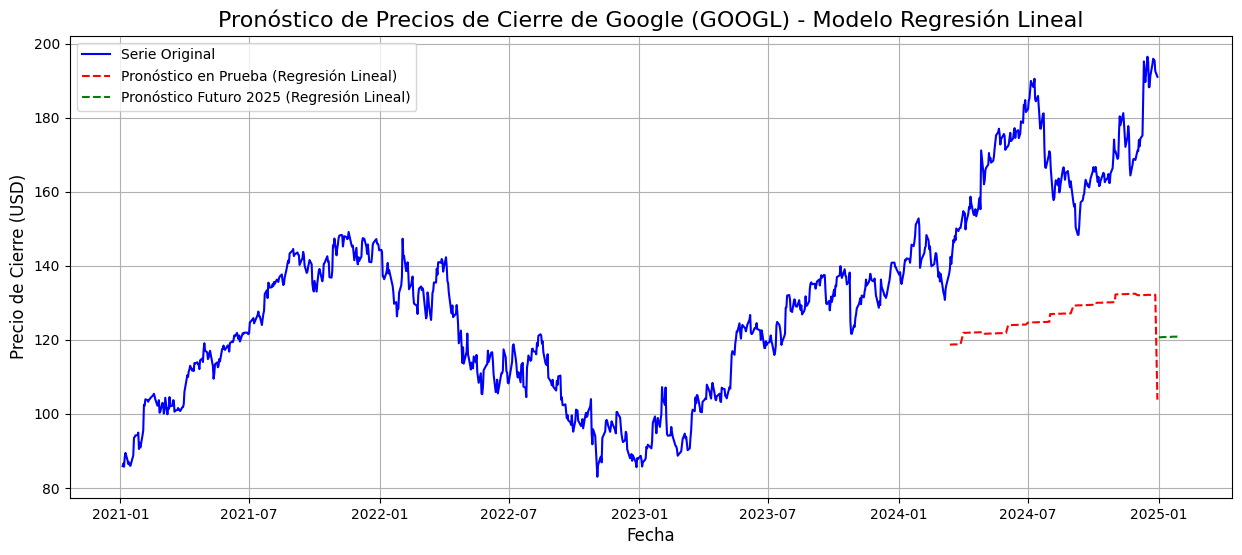

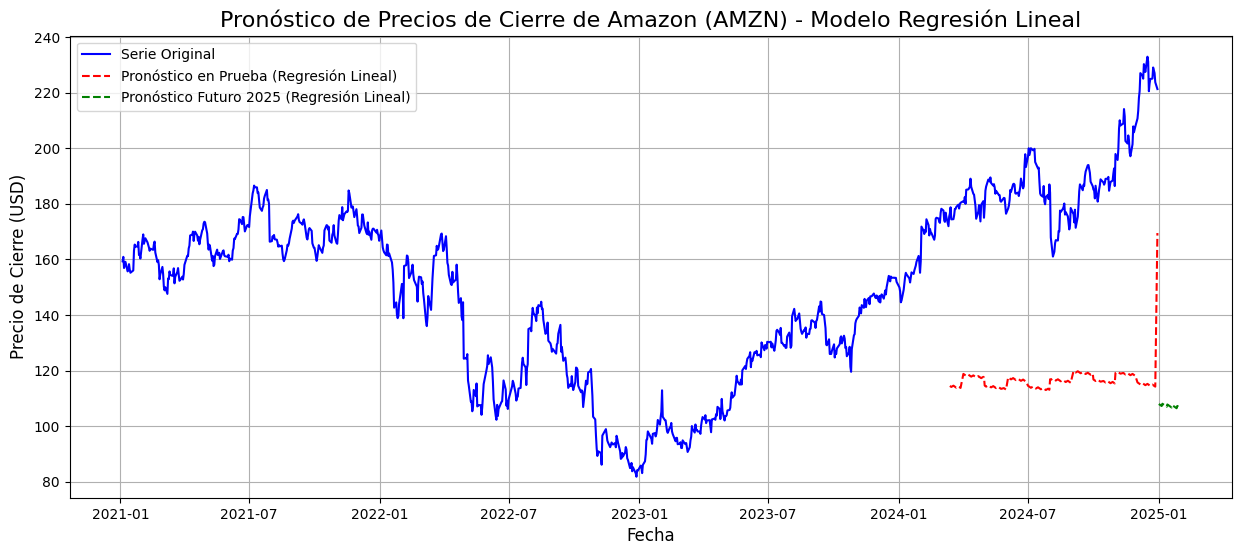

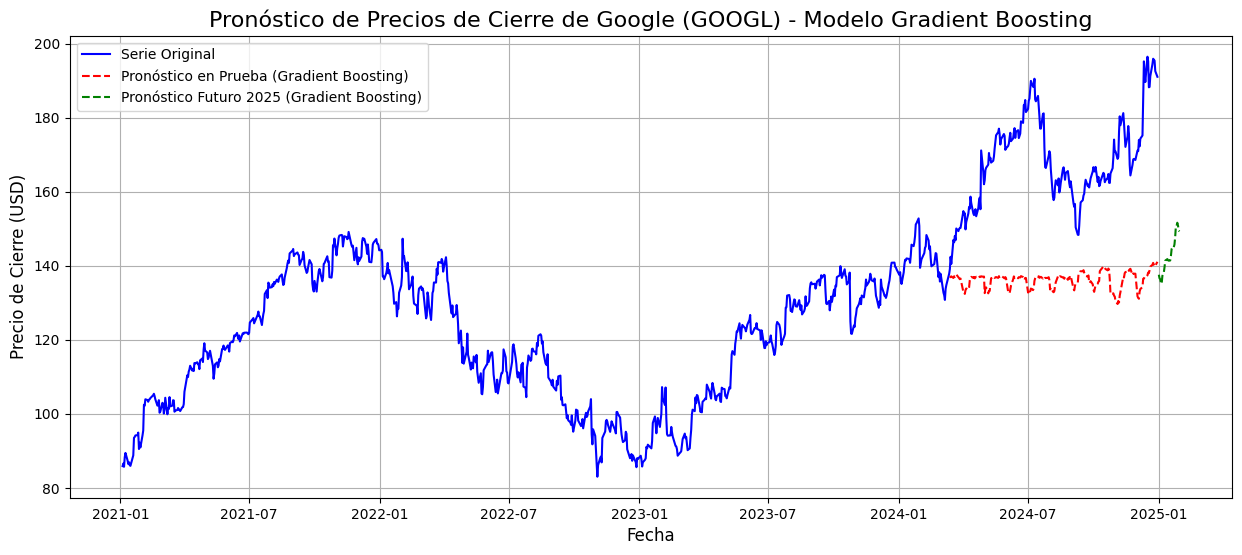

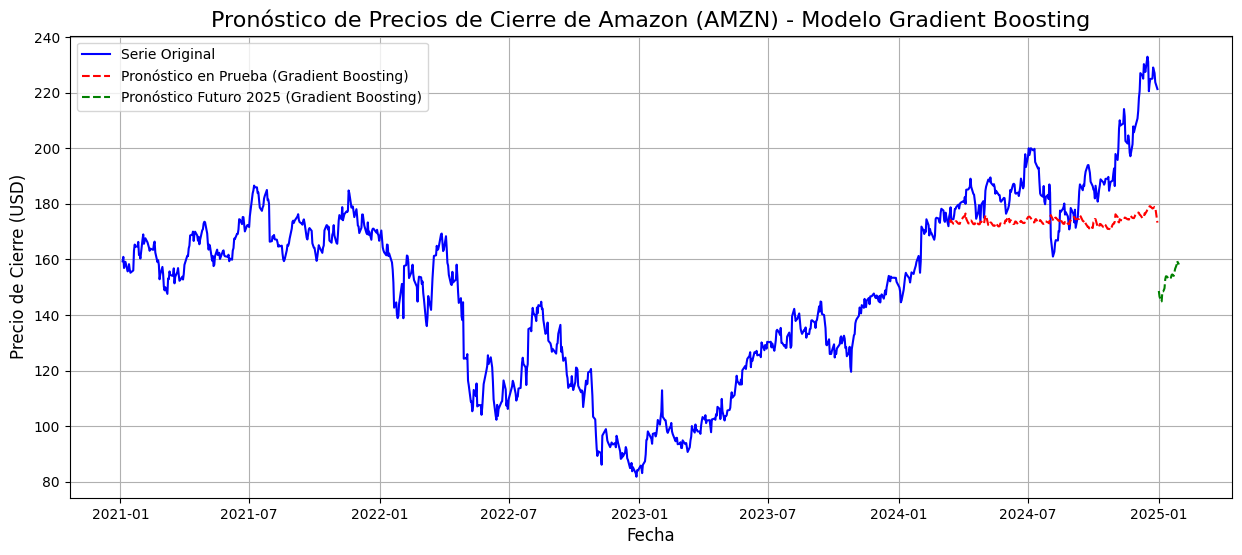

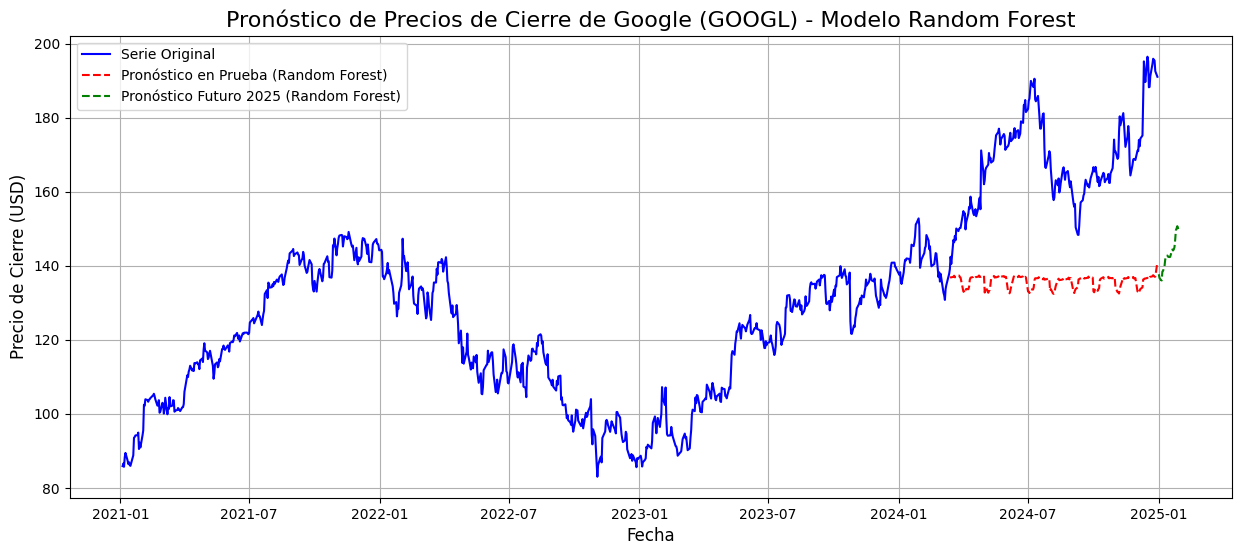

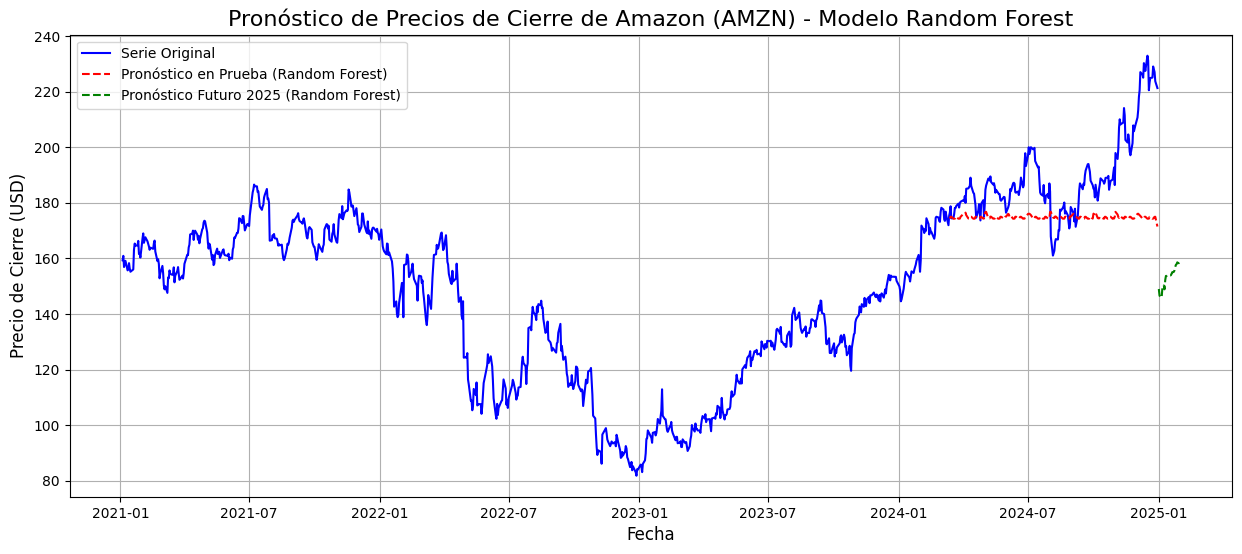

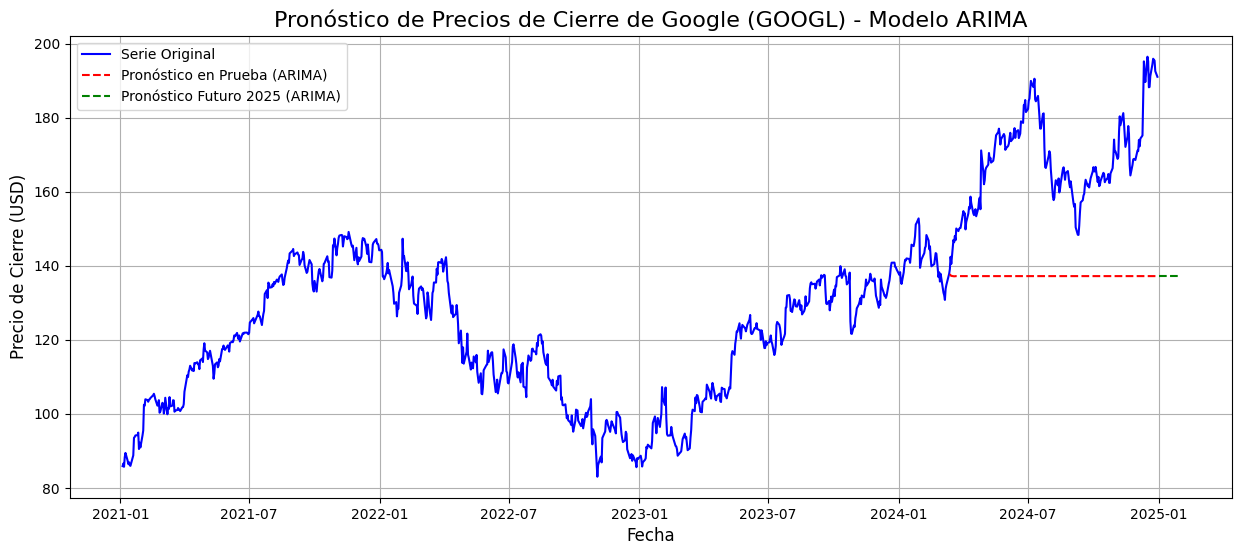

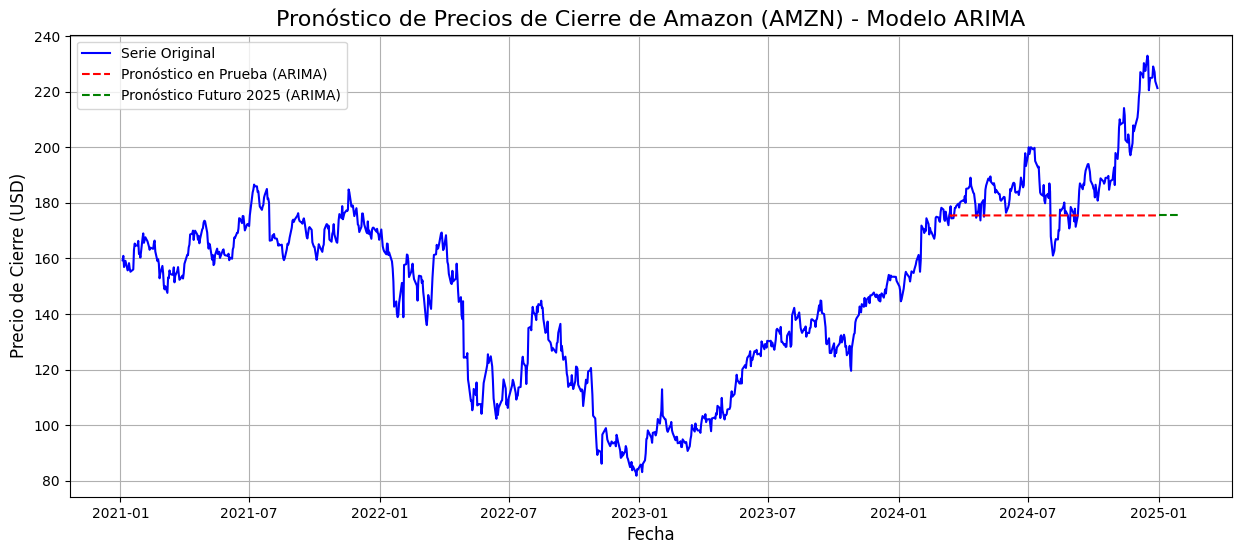

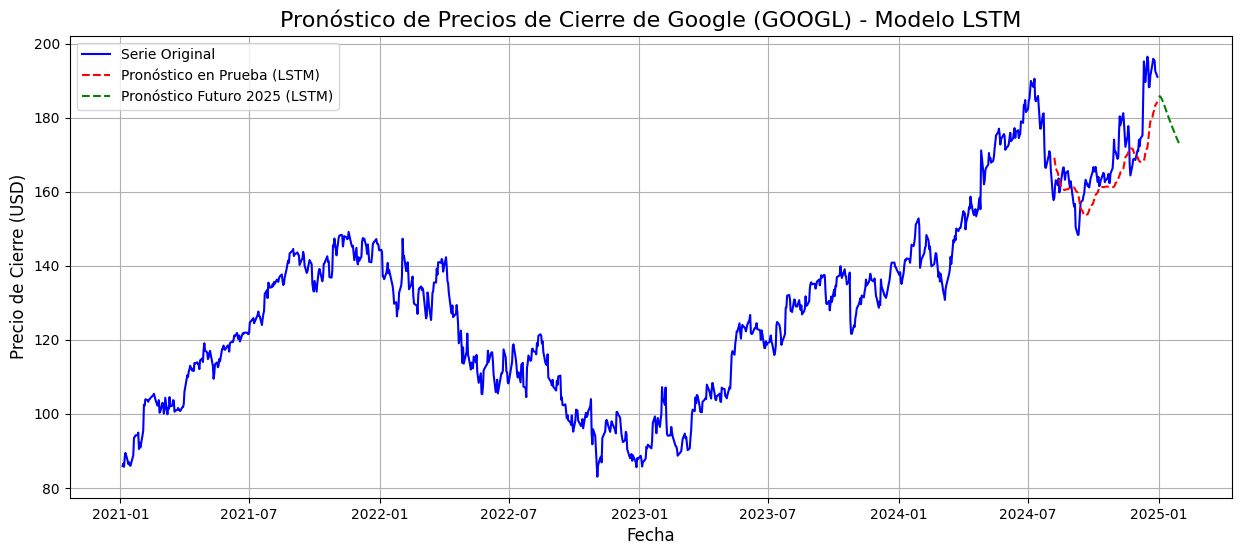

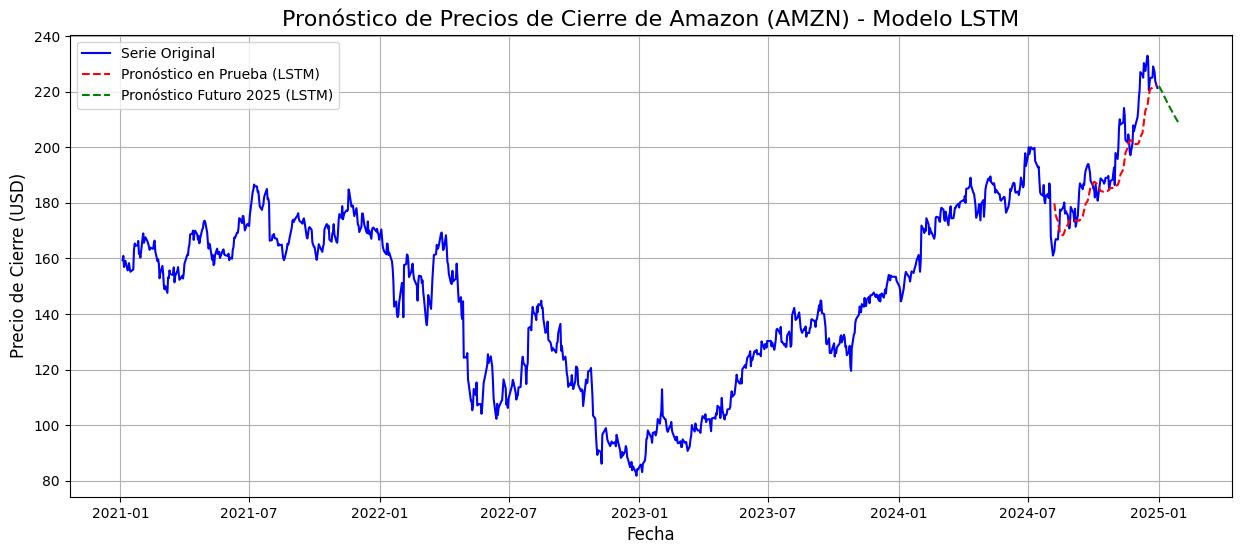

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
from keras.models import Sequential
from keras.layers import LSTM, Dense
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/jaimeisaac2020/Python-analsisis-basicos/mi-github/dataset_completo_google_amazon.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

target_google = 'GOOGL_Close'
target_amazon = 'AMZN_Close'

# Prepare data for all models
def create_features(data):
    data = data.copy()
    data['dayofweek'] = data.index.dayofweek
    data['quarter'] = data.index.quarter
    data['month'] = data.index.month
    data['year'] = data.index.year
    data['dayofyear'] = data.index.dayofyear
    data['dayofmonth'] = data.index.day
    data['weekofyear'] = data.index.isocalendar().week
    return data

df_features = create_features(df)
train_size = int(len(df_features) * 0.8)
df_train_features = df_features.iloc[:train_size]
df_test_features = df_features.iloc[train_size:]
features = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear']

# Generate future dates for 2025
forecast_dates = pd.date_range(start='2025-01-01', periods=30)
forecast_df_2025 = pd.DataFrame(index=forecast_dates)
forecast_df_2025 = create_features(forecast_df_2025)

def plot_forecast(df, df_test, df_forecast, title, original_column, test_preds, forecast_preds, model_name):
    plt.figure(figsize=(15, 6))
    plt.plot(df.index, df[original_column], label='Serie Original', color='blue')
    plt.plot(df_test.index, test_preds, label=f'Pronóstico en Prueba ({model_name})', linestyle='--', color='red')
    plt.plot(df_forecast.index, forecast_preds, label=f'Pronóstico Futuro 2025 ({model_name})', linestyle='--', color='green')
    plt.title(f'Pronóstico de Precios de Cierre de {title} - Modelo {model_name}', fontsize=16)
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Precio de Cierre (USD)', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()

# --- LSTM Model ---
# LSTM specific data prep
def create_dataset_lstm(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X.append(a)
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Google
google_df = df[[target_google]]
scaler_google = MinMaxScaler(feature_range=(0, 1))
scaled_google = scaler_google.fit_transform(np.array(google_df).reshape(-1, 1))
training_size_google = int(len(scaled_google) * 0.8)
train_data_google, test_data_google = scaled_google[0:training_size_google, :], scaled_google[training_size_google:len(scaled_google), :1]
time_step = 100
X_train_google, y_train_google = create_dataset_lstm(train_data_google, time_step)
X_test_google, y_test_google = create_dataset_lstm(test_data_google, time_step)
X_train_google = X_train_google.reshape(X_train_google.shape[0], X_train_google.shape[1], 1)
X_test_google = X_test_google.reshape(X_test_google.shape[0], X_test_google.shape[1], 1)
lstm_model_google = build_lstm_model((time_step, 1))
lstm_model_google.fit(X_train_google, y_train_google, epochs=10, batch_size=64, verbose=0)
test_predict_google_lstm = lstm_model_google.predict(X_test_google)
test_predict_google_lstm = scaler_google.inverse_transform(test_predict_google_lstm)
last_100_days_google = scaled_google[len(scaled_google) - 100:].reshape(1, -1)
temp_input_google = list(last_100_days_google)
temp_input_google = temp_input_google[0].tolist()
lstm_forecast_google = []
i = 0
while(i < 30):
    if len(temp_input_google) > 100:
        x_input = np.array(temp_input_google[1:])
        x_input = x_input.reshape(1, -1)
        x_input = x_input.reshape((1, 100, 1))
        yhat = lstm_model_google.predict(x_input, verbose=0)
        temp_input_google.extend(yhat[0].tolist())
        temp_input_google = temp_input_google[1:]
        lstm_forecast_google.extend(yhat.tolist())
        i = i + 1
    else:
        x_input = np.array(temp_input_google).reshape((1, 100, 1))
        yhat = lstm_model_google.predict(x_input, verbose=0)
        temp_input_google.extend(yhat[0].tolist())
        lstm_forecast_google.extend(yhat.tolist())
        i = i + 1
lstm_forecast_google = scaler_google.inverse_transform(np.array(lstm_forecast_google).reshape(-1, 1))

# Amazon
amazon_df = df[[target_amazon]]
scaler_amazon = MinMaxScaler(feature_range=(0, 1))
scaled_amazon = scaler_amazon.fit_transform(np.array(amazon_df).reshape(-1, 1))
training_size_amazon = int(len(scaled_amazon) * 0.8)
train_data_amazon, test_data_amazon = scaled_amazon[0:training_size_amazon, :], scaled_amazon[training_size_amazon:len(scaled_amazon), :1]
X_train_amazon, y_train_amazon = create_dataset_lstm(train_data_amazon, time_step)
X_test_amazon, y_test_amazon = create_dataset_lstm(test_data_amazon, time_step)
X_train_amazon = X_train_amazon.reshape(X_train_amazon.shape[0], X_train_amazon.shape[1], 1)
X_test_amazon = X_test_amazon.reshape(X_test_amazon.shape[0], X_test_amazon.shape[1], 1)
lstm_model_amazon = build_lstm_model((time_step, 1))
lstm_model_amazon.fit(X_train_amazon, y_train_amazon, epochs=10, batch_size=64, verbose=0)
test_predict_amazon_lstm = lstm_model_amazon.predict(X_test_amazon)
test_predict_amazon_lstm = scaler_amazon.inverse_transform(test_predict_amazon_lstm)
last_100_days_amazon = scaled_amazon[len(scaled_amazon) - 100:].reshape(1, -1)
temp_input_amazon = list(last_100_days_amazon)
temp_input_amazon = temp_input_amazon[0].tolist()
lstm_forecast_amazon = []
i = 0
while(i < 30):
    if len(temp_input_amazon) > 100:
        x_input = np.array(temp_input_amazon[1:])
        x_input = x_input.reshape(1, -1)
        x_input = x_input.reshape((1, 100, 1))
        yhat = lstm_model_amazon.predict(x_input, verbose=0)
        temp_input_amazon.extend(yhat[0].tolist())
        temp_input_amazon = temp_input_amazon[1:]
        lstm_forecast_amazon.extend(yhat.tolist())
        i = i + 1
    else:
        x_input = np.array(temp_input_amazon).reshape((1, 100, 1))
        yhat = lstm_model_amazon.predict(x_input, verbose=0)
        temp_input_amazon.extend(yhat[0].tolist())
        lstm_forecast_amazon.extend(yhat.tolist())
        i = i + 1
lstm_forecast_amazon = scaler_amazon.inverse_transform(np.array(lstm_forecast_amazon).reshape(-1, 1))

# --- Linear Regression Model ---
lr_model_google = LinearRegression()
lr_model_google.fit(df_train_features[features], df_train_features[target_google])
lr_preds_google = lr_model_google.predict(df_test_features[features])
lr_forecast_google = lr_model_google.predict(forecast_df_2025[features])
plot_forecast(df, df_test_features, forecast_df_2025, 'Google (GOOGL)', target_google, lr_preds_google, lr_forecast_google, 'Regresión Lineal')

lr_model_amazon = LinearRegression()
lr_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
lr_preds_amazon = lr_model_amazon.predict(df_test_features[features])
lr_forecast_amazon = lr_model_amazon.predict(forecast_df_2025[features])
plot_forecast(df, df_test_features, forecast_df_2025, 'Amazon (AMZN)', target_amazon, lr_preds_amazon, lr_forecast_amazon, 'Regresión Lineal')

# --- Gradient Boosting Model ---
gb_model_google = GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, subsample=0.7, random_state=42)
gb_model_google.fit(df_train_features[features], df_train_features[target_google])
gb_preds_google = gb_model_google.predict(df_test_features[features])
gb_forecast_google = gb_model_google.predict(forecast_df_2025[features])
plot_forecast(df, df_test_features, forecast_df_2025, 'Google (GOOGL)', target_google, gb_preds_google, gb_forecast_google, 'Gradient Boosting')

gb_model_amazon = GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, subsample=0.7, random_state=42)
gb_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
gb_preds_amazon = gb_model_amazon.predict(df_test_features[features])
gb_forecast_amazon = gb_model_amazon.predict(forecast_df_2025[features])
plot_forecast(df, df_test_features, forecast_df_2025, 'Amazon (AMZN)', target_amazon, gb_preds_amazon, gb_forecast_amazon, 'Gradient Boosting')

# --- Random Forest Model ---
rf_model_google = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_split=2, random_state=42)
rf_model_google.fit(df_train_features[features], df_train_features[target_google])
rf_preds_google = rf_model_google.predict(df_test_features[features])
rf_forecast_google = rf_model_google.predict(forecast_df_2025[features])
plot_forecast(df, df_test_features, forecast_df_2025, 'Google (GOOGL)', target_google, rf_preds_google, rf_forecast_google, 'Random Forest')

rf_model_amazon = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_split=2, random_state=42)
rf_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
rf_preds_amazon = rf_model_amazon.predict(df_test_features[features])
rf_forecast_amazon = rf_model_amazon.predict(forecast_df_2025[features])
plot_forecast(df, df_test_features, forecast_df_2025, 'Amazon (AMZN)', target_amazon, rf_preds_amazon, rf_forecast_amazon, 'Random Forest')

# --- ARIMA Model ---
arima_model_google = ARIMA(df_features[target_google].iloc[:train_size], order=(5,1,0))
arima_model_google_fit = arima_model_google.fit()
arima_preds_google = arima_model_google_fit.predict(start=len(df_train_features), end=len(df_features)-1)
arima_forecast_google = arima_model_google_fit.predict(start=len(df), end=len(df) + 30 - 1)
plot_forecast(df, df_test_features, forecast_df_2025, 'Google (GOOGL)', target_google, arima_preds_google, arima_forecast_google, 'ARIMA')

arima_model_amazon = ARIMA(df_features[target_amazon].iloc[:train_size], order=(5,1,0))
arima_model_amazon_fit = arima_model_amazon.fit()
arima_preds_amazon = arima_model_amazon_fit.predict(start=len(df_train_features), end=len(df_features)-1)
arima_forecast_amazon = arima_model_amazon_fit.predict(start=len(df), end=len(df) + 30 - 1)
plot_forecast(df, df_test_features, forecast_df_2025, 'Amazon (AMZN)', target_amazon, arima_preds_amazon, arima_forecast_amazon, 'ARIMA')

# --- LSTM Plotting ---
plot_forecast(df, df.iloc[training_size_google + 101:], forecast_df_2025, 'Google (GOOGL)', target_google, test_predict_google_lstm, lstm_forecast_google, 'LSTM')
plot_forecast(df, df.iloc[training_size_amazon + 101:], forecast_df_2025, 'Amazon (AMZN)', target_amazon, test_predict_amazon_lstm, lstm_forecast_amazon, 'LSTM')

In [8]:
import pandas as pd

# Load the dataframes with features and forecasts from the previous script
# df_test_features, forecast_df_2025, etc.

# --- Prepare Forecast DataFrames for each model ---

# ARIMA
arima_forecast_google_df = pd.DataFrame(arima_forecast_google, index=forecast_df_2025.index, columns=['Pronóstico Google (GOOGL)'])
arima_forecast_amazon_df = pd.DataFrame(arima_forecast_amazon, index=forecast_df_2025.index, columns=['Pronóstico Amazon (AMZN)'])
arima_forecast_df = pd.concat([arima_forecast_google_df, arima_forecast_amazon_df], axis=1)
arima_forecast_df['Modelo'] = 'ARIMA'

# LSTM
lstm_forecast_google_df = pd.DataFrame(lstm_forecast_google, index=forecast_df_2025.index, columns=['Pronóstico Google (GOOGL)'])
lstm_forecast_amazon_df = pd.DataFrame(lstm_forecast_amazon, index=forecast_df_2025.index, columns=['Pronóstico Amazon (AMZN)'])
lstm_forecast_df = pd.concat([lstm_forecast_google_df, lstm_forecast_amazon_df], axis=1)
lstm_forecast_df['Modelo'] = 'LSTM'

# Random Forest
rf_forecast_google_df = pd.DataFrame(rf_forecast_google, index=forecast_df_2025.index, columns=['Pronóstico Google (GOOGL)'])
rf_forecast_amazon_df = pd.DataFrame(rf_forecast_amazon, index=forecast_df_2025.index, columns=['Pronóstico Amazon (AMZN)'])
rf_forecast_df = pd.concat([rf_forecast_google_df, rf_forecast_amazon_df], axis=1)
rf_forecast_df['Modelo'] = 'Random Forest'

# Gradient Boosting
gb_forecast_google_df = pd.DataFrame(gb_forecast_google, index=forecast_df_2025.index, columns=['Pronóstico Google (GOOGL)'])
gb_forecast_amazon_df = pd.DataFrame(gb_forecast_amazon, index=forecast_df_2025.index, columns=['Pronóstico Amazon (AMZN)'])
gb_forecast_df = pd.concat([gb_forecast_google_df, gb_forecast_amazon_df], axis=1)
gb_forecast_df['Modelo'] = 'Gradient Boosting'

# Concatenate all forecast dataframes
all_forecasts = pd.concat([arima_forecast_df, lstm_forecast_df, rf_forecast_df, gb_forecast_df])

# Format and print the table
all_forecasts.index.name = 'Fecha'
all_forecasts['Pronóstico Google (GOOGL)'] = all_forecasts['Pronóstico Google (GOOGL)'].round(2)
all_forecasts['Pronóstico Amazon (AMZN)'] = all_forecasts['Pronóstico Amazon (AMZN)'].round(2)

print("\n=== Tabla de Pronósticos de Precios Futuros (Enero 2025) ===")
print(all_forecasts)


=== Tabla de Pronósticos de Precios Futuros (Enero 2025) ===
            Pronóstico Google (GOOGL)  Pronóstico Amazon (AMZN)  \
Fecha                                                             
2025-01-01                        NaN                       NaN   
2025-01-02                        NaN                       NaN   
2025-01-03                        NaN                       NaN   
2025-01-04                        NaN                       NaN   
2025-01-05                        NaN                       NaN   
...                               ...                       ...   
2025-01-26                     150.78                    158.05   
2025-01-27                     151.62                    159.44   
2025-01-28                     150.83                    158.49   
2025-01-29                     149.48                    158.52   
2025-01-30                     149.28                    158.65   

                       Modelo  
Fecha                          
20

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/jaimeisaac2020/Python-analsisis-basicos/mi-github/dataset_completo_google_amazon.csv')

# Preprocess the data
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Select the target variables
target_google = 'GOOGL_Close'
target_amazon = 'AMZN_Close'

# --- Prepare data for all models ---
def create_features(data):
    data = data.copy()
    data['dayofweek'] = data.index.dayofweek
    data['quarter'] = data.index.quarter
    data['month'] = data.index.month
    data['year'] = data.index.year
    data['dayofyear'] = data.index.dayofyear
    data['dayofmonth'] = data.index.day
    data['weekofyear'] = data.index.isocalendar().week
    return data

df_features = create_features(df)
train_size = int(len(df_features) * 0.8)
df_train_features = df_features.iloc[:train_size]
df_test_features = df_features.iloc[train_size:]
features = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear']

# Generate future dates for 2025 (2 months)
forecast_dates = pd.date_range(start='2025-01-01', periods=60)
forecast_df_2025 = pd.DataFrame(index=forecast_dates)
forecast_df_2025 = create_features(forecast_df_2025)

# --- LSTM Model ---
# LSTM specific data prep
def create_dataset_lstm(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X.append(a)
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Google LSTM
google_df = df[[target_google]]
scaler_google = MinMaxScaler(feature_range=(0, 1))
scaled_google = scaler_google.fit_transform(np.array(google_df).reshape(-1, 1))
training_size_google = int(len(scaled_google) * 0.8)
last_100_days_google = scaled_google[len(scaled_google) - 100:].reshape(1, -1)
temp_input_google = list(last_100_days_google)
temp_input_google = temp_input_google[0].tolist()
lstm_forecast_google = []
lstm_model_google = build_lstm_model((100, 1))
lstm_model_google.fit(create_dataset_lstm(scaled_google[:training_size_google,:], 100)[0].reshape(len(create_dataset_lstm(scaled_google[:training_size_google,:], 100)[0]), 100, 1), create_dataset_lstm(scaled_google[:training_size_google,:], 100)[1], epochs=10, batch_size=64, verbose=0)
i = 0
while(i < 60):
    if len(temp_input_google) > 100:
        x_input = np.array(temp_input_google[1:])
        x_input = x_input.reshape(1, -1)
        x_input = x_input.reshape((1, 100, 1))
        yhat = lstm_model_google.predict(x_input, verbose=0)
        temp_input_google.extend(yhat[0].tolist())
        temp_input_google = temp_input_google[1:]
        lstm_forecast_google.extend(yhat.tolist())
        i = i + 1
    else:
        x_input = np.array(temp_input_google).reshape((1, 100, 1))
        yhat = lstm_model_google.predict(x_input, verbose=0)
        temp_input_google.extend(yhat[0].tolist())
        lstm_forecast_google.extend(yhat.tolist())
        i = i + 1
lstm_forecast_google = scaler_google.inverse_transform(np.array(lstm_forecast_google).reshape(-1, 1))

# Amazon LSTM
amazon_df = df[[target_amazon]]
scaler_amazon = MinMaxScaler(feature_range=(0, 1))
scaled_amazon = scaler_amazon.fit_transform(np.array(amazon_df).reshape(-1, 1))
training_size_amazon = int(len(scaled_amazon) * 0.8)
last_100_days_amazon = scaled_amazon[len(scaled_amazon) - 100:].reshape(1, -1)
temp_input_amazon = list(last_100_days_amazon)
temp_input_amazon = temp_input_amazon[0].tolist()
lstm_forecast_amazon = []
lstm_model_amazon = build_lstm_model((100, 1))
lstm_model_amazon.fit(create_dataset_lstm(scaled_amazon[:training_size_amazon,:], 100)[0].reshape(len(create_dataset_lstm(scaled_amazon[:training_size_amazon,:], 100)[0]), 100, 1), create_dataset_lstm(scaled_amazon[:training_size_amazon,:], 100)[1], epochs=10, batch_size=64, verbose=0)
i = 0
while(i < 60):
    if len(temp_input_amazon) > 100:
        x_input = np.array(temp_input_amazon[1:])
        x_input = x_input.reshape(1, -1)
        x_input = x_input.reshape((1, 100, 1))
        yhat = lstm_model_amazon.predict(x_input, verbose=0)
        temp_input_amazon.extend(yhat[0].tolist())
        temp_input_amazon = temp_input_amazon[1:]
        lstm_forecast_amazon.extend(yhat.tolist())
        i = i + 1
    else:
        x_input = np.array(temp_input_amazon).reshape((1, 100, 1))
        yhat = lstm_model_amazon.predict(x_input, verbose=0)
        temp_input_amazon.extend(yhat[0].tolist())
        lstm_forecast_amazon.extend(yhat.tolist())
        i = i + 1
lstm_forecast_amazon = scaler_amazon.inverse_transform(np.array(lstm_forecast_amazon).reshape(-1, 1))

# --- Random Forest Model ---
rf_model_google = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_split=2, random_state=42)
rf_model_google.fit(df_train_features[features], df_train_features[target_google])
rf_forecast_google = rf_model_google.predict(forecast_df_2025[features])
rf_model_amazon = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_split=2, random_state=42)
rf_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
rf_forecast_amazon = rf_model_amazon.predict(forecast_df_2025[features])

# --- Gradient Boosting Model ---
gb_model_google = GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, subsample=0.7, random_state=42)
gb_model_google.fit(df_train_features[features], df_train_features[target_google])
gb_forecast_google = gb_model_google.predict(forecast_df_2025[features])
gb_model_amazon = GradientBoostingRegressor(n_estimators=500, max_depth=5, learning_rate=0.01, subsample=0.7, random_state=42)
gb_model_amazon.fit(df_train_features[features], df_train_features[target_amazon])
gb_forecast_amazon = gb_model_amazon.predict(forecast_df_2025[features])

# --- ARIMA Model ---
arima_model_google = ARIMA(df_features[target_google].iloc[:train_size], order=(5,1,0))
arima_model_google_fit = arima_model_google.fit()
arima_forecast_google = arima_model_google_fit.predict(start=len(df), end=len(df) + 60 - 1)
arima_model_amazon = ARIMA(df_features[target_amazon].iloc[:train_size], order=(5,1,0))
arima_model_amazon_fit = arima_model_amazon.fit()
arima_forecast_amazon = arima_model_amazon_fit.predict(start=len(df), end=len(df) + 60 - 1)

# --- Prepare Forecast DataFrames for each model ---
arima_forecast_google_df = pd.DataFrame(arima_forecast_google.values, index=forecast_df_2025.index, columns=['Pronóstico Google (GOOGL)'])
arima_forecast_amazon_df = pd.DataFrame(arima_forecast_amazon.values, index=forecast_df_2025.index, columns=['Pronóstico Amazon (AMZN)'])
arima_forecast_df = pd.concat([arima_forecast_google_df, arima_forecast_amazon_df], axis=1)
arima_forecast_df['Modelo'] = 'ARIMA'

lstm_forecast_google_df = pd.DataFrame(lstm_forecast_google, index=forecast_df_2025.index, columns=['Pronóstico Google (GOOGL)'])
lstm_forecast_amazon_df = pd.DataFrame(lstm_forecast_amazon, index=forecast_df_2025.index, columns=['Pronóstico Amazon (AMZN)'])
lstm_forecast_df = pd.concat([lstm_forecast_google_df, lstm_forecast_amazon_df], axis=1)
lstm_forecast_df['Modelo'] = 'LSTM'

rf_forecast_google_df = pd.DataFrame(rf_forecast_google, index=forecast_df_2025.index, columns=['Pronóstico Google (GOOGL)'])
rf_forecast_amazon_df = pd.DataFrame(rf_forecast_amazon, index=forecast_df_2025.index, columns=['Pronóstico Amazon (AMZN)'])
rf_forecast_df = pd.concat([rf_forecast_google_df, rf_forecast_amazon_df], axis=1)
rf_forecast_df['Modelo'] = 'Random Forest'

gb_forecast_google_df = pd.DataFrame(gb_forecast_google, index=forecast_df_2025.index, columns=['Pronóstico Google (GOOGL)'])
gb_forecast_amazon_df = pd.DataFrame(gb_forecast_amazon, index=forecast_df_2025.index, columns=['Pronóstico Amazon (AMZN)'])
gb_forecast_df = pd.concat([gb_forecast_google_df, gb_forecast_amazon_df], axis=1)
gb_forecast_df['Modelo'] = 'Gradient Boosting'

# Concatenate all forecast dataframes
all_forecasts = pd.concat([arima_forecast_df, lstm_forecast_df, rf_forecast_df, gb_forecast_df])

# Format and print the table
all_forecasts.index.name = 'Fecha'
all_forecasts['Pronóstico Google (GOOGL)'] = all_forecasts['Pronóstico Google (GOOGL)'].round(2)
all_forecasts['Pronóstico Amazon (AMZN)'] = all_forecasts['Pronóstico Amazon (AMZN)'].round(2)

print("\n=== Tabla de Pronósticos de Precios Futuros (Enero y Febrero 2025) ===")
print(all_forecasts.to_string())


=== Tabla de Pronósticos de Precios Futuros (Enero y Febrero 2025) ===
            Pronóstico Google (GOOGL)  Pronóstico Amazon (AMZN)             Modelo
Fecha                                                                             
2025-01-01                     137.20                    175.47              ARIMA
2025-01-02                     137.20                    175.47              ARIMA
2025-01-03                     137.20                    175.47              ARIMA
2025-01-04                     137.20                    175.47              ARIMA
2025-01-05                     137.20                    175.47              ARIMA
2025-01-06                     137.20                    175.47              ARIMA
2025-01-07                     137.20                    175.47              ARIMA
2025-01-08                     137.20                    175.47              ARIMA
2025-01-09                     137.20                    175.47              ARIMA
2025-01-10     

In [10]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# --- Asumiendo que el código de pronóstico ya se ha ejecutado y las variables están disponibles:
# lstm_forecast_google, lstm_forecast_amazon, rf_forecast_google, rf_forecast_amazon, etc.
# y las fechas de pronóstico en forecast_df_2025.index

# --- Paso 1: Descargar datos reales (esto fallará sin acceso a internet) ---
try:
    print("Descargando precios de cierre reales para 2025...")
    real_prices = yf.download(
        tickers="GOOGL AMZN",
        start="2025-01-01",
        end="2025-03-01",
        progress=False,
    )
    real_prices = real_prices['Adj Close']
    real_prices.columns = ['AMZN_Real', 'GOOGL_Real']

    # Asegurarse de que los índices coincidan
    real_prices = real_prices.reindex(forecast_df_2025.index)
    print("Descarga completada.")

    # --- Paso 2: Crear la tabla de comparación ---
    comparison_table = pd.DataFrame(index=forecast_df_2025.index)
    comparison_table['GOOGL_Real'] = real_prices['GOOGL_Real']
    comparison_table['AMZN_Real'] = real_prices['AMZN_Real']

    # Agregar pronósticos
    comparison_table['GOOGL_LSTM_Pred'] = lstm_forecast_google.flatten()[:len(comparison_table)]
    comparison_table['AMZN_LSTM_Pred'] = lstm_forecast_amazon.flatten()[:len(comparison_table)]
    comparison_table['GOOGL_RF_Pred'] = rf_forecast_google[:len(comparison_table)]
    comparison_table['AMZN_RF_Pred'] = rf_forecast_amazon[:len(comparison_table)]
    comparison_table['GOOGL_GB_Pred'] = gb_forecast_google[:len(comparison_table)]
    comparison_table['AMZN_GB_Pred'] = gb_forecast_amazon[:len(comparison_table)]
    comparison_table['GOOGL_ARIMA_Pred'] = arima_forecast_google[:len(comparison_table)]
    comparison_table['AMZN_ARIMA_Pred'] = arima_forecast_amazon[:len(comparison_table)]

    # Calcular métricas de error
    metrics_table = pd.DataFrame(index=['GOOGL', 'AMZN'])
    metrics_table['LSTM_MSE'] = [
        mean_squared_error(comparison_table['GOOGL_Real'].dropna(), comparison_table['GOOGL_LSTM_Pred'].dropna()),
        mean_squared_error(comparison_table['AMZN_Real'].dropna(), comparison_table['AMZN_LSTM_Pred'].dropna())
    ]
    metrics_table['RF_MSE'] = [
        mean_squared_error(comparison_table['GOOGL_Real'].dropna(), comparison_table['GOOGL_RF_Pred'].dropna()),
        mean_squared_error(comparison_table['AMZN_Real'].dropna(), comparison_table['AMZN_RF_Pred'].dropna())
    ]
    metrics_table['GB_MSE'] = [
        mean_squared_error(comparison_table['GOOGL_Real'].dropna(), comparison_table['GOOGL_GB_Pred'].dropna()),
        mean_squared_error(comparison_table['AMZN_Real'].dropna(), comparison_table['AMZN_GB_Pred'].dropna())
    ]
    metrics_table['ARIMA_MSE'] = [
        mean_squared_error(comparison_table['GOOGL_Real'].dropna(), comparison_table['GOOGL_ARIMA_Pred'].dropna()),
        mean_squared_error(comparison_table['AMZN_Real'].dropna(), comparison_table['AMZN_ARIMA_Pred'].dropna())
    ]

    # Imprimir la tabla de pronósticos y la tabla de métricas
    print("\nTabla de Pronósticos vs. Precios Reales (Enero-Febrero 2025)")
    print(comparison_table.head())
    print("\nTabla de Métricas de Error (MSE)")
    print(metrics_table)

except Exception as e:
    print(f"Error al intentar descargar datos: {e}")
    print("No se puede realizar la comparación sin datos reales.")

Descargando precios de cierre reales para 2025...
Error al intentar descargar datos: 'Adj Close'
No se puede realizar la comparación sin datos reales.


In [ ]:
!pip install yfinance

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# --- Paso 1: Genera los pronósticos (ejecuta el código anterior) ---
# Asegúrate de tener las variables:
# lstm_forecast_google, lstm_forecast_amazon
# rf_forecast_google, rf_forecast_amazon
# gb_forecast_google, gb_forecast_amazon
# arima_forecast_google, arima_forecast_amazon
# forecast_df_2025 (DataFrame con las fechas de pronóstico)

# --- Paso 2: Descarga los datos reales ---
print("Descargando precios de cierre reales para 2025...")
try:
    tickers_list = ["GOOGL", "AMZN"]
    real_prices = yf.download(
        tickers=tickers_list,
        start="2025-01-01",
        end="2025-03-01",
        group_by='ticker',
        progress=False
    )

    # Extraer los precios de cierre ajustados y renombrar columnas
    googl_real = real_prices['GOOGL']['Adj Close']
    amzn_real = real_prices['AMZN']['Adj Close']

    # Unir los precios reales en un solo DataFrame
    real_prices_df = pd.DataFrame({
        'GOOGL_Real': googl_real,
        'AMZN_Real': amzn_real
    })

    # Asegurarse de que el índice de fechas de los pronósticos coincida con el de los datos reales
    real_prices_df = real_prices_df.reindex(forecast_df_2025.index)
    real_prices_df.dropna(inplace=True) # Eliminar días sin operaciones

    # --- Paso 3: Alinear y comparar los pronósticos con los datos reales ---

    # Asegurarse de que los arrays de pronósticos tengan la misma longitud que los datos reales
    num_days = len(real_prices_df)

    lstm_forecast_google_aligned = lstm_forecast_google[:num_days]
    lstm_forecast_amazon_aligned = lstm_forecast_amazon[:num_days]
    rf_forecast_google_aligned = rf_forecast_google[:num_days]
    rf_forecast_amazon_aligned = rf_forecast_amazon[:num_days]
    gb_forecast_google_aligned = gb_forecast_google[:num_days]
    gb_forecast_amazon_aligned = gb_forecast_amazon[:num_days]
    arima_forecast_google_aligned = arima_forecast_google[:num_days]
    arima_forecast_amazon_aligned = arima_forecast_amazon[:num_days]

    # Crear una tabla de comparación
    comparison_table_googl = pd.DataFrame({
        'Real': real_prices_df['GOOGL_Real'],
        'LSTM': lstm_forecast_google_aligned.flatten(),
        'ARIMA': arima_forecast_google_aligned.values,
        'Random Forest': rf_forecast_google_aligned,
        'Gradient Boosting': gb_forecast_google_aligned
    })

    comparison_table_amzn = pd.DataFrame({
        'Real': real_prices_df['AMZN_Real'],
        'LSTM': lstm_forecast_amazon_aligned.flatten(),
        'ARIMA': arima_forecast_amazon_aligned.values,
        'Random Forest': rf_forecast_amazon_aligned,
        'Gradient Boosting': gb_forecast_amazon_aligned
    })

    # --- Paso 4: Calcular métricas de error ---
    metrics = {
        'Modelo': ['LSTM', 'ARIMA', 'Random Forest', 'Gradient Boosting'],
        'MSE_GOOGL': [
            mean_squared_error(comparison_table_googl['Real'], comparison_table_googl['LSTM']),
            mean_squared_error(comparison_table_googl['Real'], comparison_table_googl['ARIMA']),
            mean_squared_error(comparison_table_googl['Real'], comparison_table_googl['Random Forest']),
            mean_squared_error(comparison_table_googl['Real'], comparison_table_googl['Gradient Boosting'])
        ],
        'MSE_AMZN': [
            mean_squared_error(comparison_table_amzn['Real'], comparison_table_amzn['LSTM']),
            mean_squared_error(comparison_table_amzn['Real'], comparison_table_amzn['ARIMA']),
            mean_squared_error(comparison_table_amzn['Real'], comparison_table_amzn['Random Forest']),
            mean_squared_error(comparison_table_amzn['Real'], comparison_table_amzn['Gradient Boosting'])
        ]
    }

    metrics_df = pd.DataFrame(metrics)
    metrics_df.set_index('Modelo', inplace=True)

    print("\nTabla de Pronósticos de Google vs. Datos Reales")
    print(comparison_table_googl.to_string())

    print("\nTabla de Pronósticos de Amazon vs. Datos Reales")
    print(comparison_table_amzn.to_string())

    print("\nTabla de Rendimiento de Modelos (MSE)")
    print(metrics_df.to_string())

except Exception as e:
    print(f"Ocurrió un error al descargar los datos reales: {e}")
    print("Por favor, asegúrate de que tienes conexión a internet y la librería 'yfinance' instalada.")

Descargando precios de cierre reales para 2025...
Ocurrió un error al descargar los datos reales: 'Adj Close'
Por favor, asegúrate de que tienes conexión a internet y la librería 'yfinance' instalada.
